In [8]:
import pandas as pd
import re
import os
import numpy as np
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter


In [9]:

import geopandas as gpd
import pycountry
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


In [11]:
import time
from bs4 import BeautifulSoup     

In [12]:
import sys
from pathlib import Path

# 1. Figure out where you are
notebook_dir = Path().cwd()  

# 2. Build the path to the module folder
viz_folder = notebook_dir.parent / "06_preclin_clinic_join"

# 3. Insert it onto sys.path
sys.path.insert(0, str(viz_folder.resolve()))

# 4. Now import
from viz_data import plot_top_entities_side_by_side


In [13]:
df_path = "../06_preclin_clinic_join/data/joined_data/preclinical_metadata_mapped_annotated_20250723_norm_strain_country.csv"
filtered_df_non_empty = pd.read_csv(df_path)
filtered_df_non_empty.shape

(94841, 29)

In [14]:
filtered_df_non_empty = filtered_df_non_empty[filtered_df_non_empty['animal_strain']!='no full text']

In [18]:
filtered_df_non_empty.shape

(32762, 29)

In [19]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

def _safe_filename(s: str) -> str:
    s = s.strip()
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^A-Za-z0-9_\-\.]", "", s)
    return s

def plot_counts_and_trends(
    df: pd.DataFrame,
    column_with_comma_values: str,
    selected_disease: str,
    top_n: int = 10,
    max_label_length: int = 15,
    include_rest: bool = False,
    min_yearly_papers: int = 10,
    out_dir: str = "viz",
    figsize=(21, 10),
    # --- legend pane placement in figure coordinates [0..1]
    legend_left: float = 0.82,
    legend_bottom: float = 0.18,
    legend_width: float = 0.15,
    legend_height: float = 0.70,
    # spacing between the two main plots only
    plots_wspace: float = 0.23,
):
    """
    Two plots side-by-side with the legend placed in a separate figure axis:
      (left)  Bar chart of total unique PMID counts for Top-N values
      (right) Prevalence over time (share of papers per year) for the same Top-N
      (separate) Legend axis positioned via figure coordinates (never clipped)

    The legend spacing is independent from plot spacing.
    """

    # -------- Data Prep --------
    exploded_df = df.copy()
    col = column_with_comma_values

    exploded_df[col] = exploded_df[col].fillna('')
    exploded_df[col] = exploded_df[col].astype(str).str.split(',')
    exploded_df = exploded_df.explode(col)
    exploded_df[col] = exploded_df[col].astype(str).str.strip()
    exploded_df = exploded_df[exploded_df[col] != '']

    # Optional: truncate long labels
    if max_label_length is not None and max_label_length > 0:
        exploded_df[col] = exploded_df[col].apply(
            lambda x: (x[:max_label_length] + "…") if len(x) > max_label_length else x
        )

    # Top-N by total unique PMIDs
    total_counts = exploded_df.groupby(col)['PMID'].nunique()
    top_values = total_counts.sort_values(ascending=False).head(top_n).index.tolist()

    filtered_df = exploded_df[exploded_df[col].isin(top_values)]
    total_counts_filtered = (
        filtered_df.groupby(col)['PMID']
        .nunique()
        .sort_values(ascending=False)
    )

    # Yearly totals
    yearly_totals = exploded_df.groupby('year')['PMID'].nunique().sort_index()
    valid_years = yearly_totals[yearly_totals >= min_yearly_papers].index

    # Yearly counts for Top-N
    top_yearly = (
        exploded_df[
            exploded_df[col].isin(top_values) &
            exploded_df['year'].isin(valid_years)
        ]
        .groupby(['year', col])['PMID']
        .nunique()
        .unstack(fill_value=0)
        .reindex(valid_years, fill_value=0)
    )

    # Ensure columns follow Top-N order
    for c in top_values:
        if c not in top_yearly.columns:
            top_yearly[c] = 0
    top_yearly = top_yearly[top_values]

    # Optional "Rest"
    if include_rest:
        any_top = (
            exploded_df[
                exploded_df[col].isin(top_values) &
                exploded_df['year'].isin(valid_years)
            ]
            .groupby(['year', 'PMID']).size().reset_index(name='n')
            .groupby('year')['PMID'].nunique()
            .reindex(valid_years, fill_value=0)
        )
        rest_counts = (yearly_totals.reindex(valid_years) - any_top).clip(lower=0)
        top_yearly['Rest'] = rest_counts

    # Prevalence (proportions)
    denom = yearly_totals.reindex(valid_years).replace(0, pd.NA)
    with pd.option_context('mode.use_inf_as_na', True):
        prevalence = top_yearly.div(denom, axis=0).fillna(0)

    # -------- Plotting with independent legend axis --------
    fig = plt.figure(figsize=figsize)

    # Two main plots (bar | line) with their own wspace
    gs_plots = fig.add_gridspec(
        1, 2,
        width_ratios=[1.0, 1.0],
        wspace=plots_wspace  # spacing only between the two plots
    )
    ax_bar = fig.add_subplot(gs_plots[0, 0])
    ax_line = fig.add_subplot(gs_plots[0, 1])

    # Legend axis defined in absolute figure coordinates (left, bottom, width, height)
    ax_leg = fig.add_axes([legend_left, legend_bottom, legend_width, legend_height])
    ax_leg.axis('off')  # no frame/ticks on the axis itself

    title_col_name = col.replace("_", " ").title()

    # Left: bar chart
    total_counts_filtered.plot(kind='bar', ax=ax_bar, legend=False)
    ax_bar.set_title(f'Top {top_n} {title_col_name}', fontsize=26)
    ax_bar.set_xlabel('', fontsize=18)
    ax_bar.set_ylabel('Unique PMID Count', fontsize=25)
    ax_bar.tick_params(axis='x', rotation=90, labelsize=28)
    ax_bar.tick_params(axis='y', labelsize=25)
    ax_bar.margins(x=0.02)

    # Right: prevalence over time (no legend here)
    prevalence.plot(ax=ax_line, legend=False)
    ax_line.set_title(
        f'Prevalence Over Time\n'
        f'(years with ≥{min_yearly_papers} papers)',
        fontsize=26
    )
    ax_line.set_xlabel('', fontsize=18)
    ax_line.set_ylabel('', fontsize=18)
    ax_line.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax_line.set_ylim(0, 1)
    ax_line.tick_params(axis='x', labelsize=28)
    ax_line.tick_params(axis='y', labelsize=25)
    ax_line.margins(x=0.02)

    # --- Legend drawn inside the dedicated axis (won't be clipped) ---
    handles, labels = ax_line.get_legend_handles_labels()
    if not labels:
        handles = ax_line.lines
        labels = [l.get_label() for l in handles]

    ncols = 1 if len(labels) <= 18 else 2  # auto split if many series

    leg = ax_leg.legend(
        handles, labels,
        title=col,
        loc="upper left",
        frameon=True,          # draw a box around the legend
        fontsize=24,
        title_fontsize=24,
        ncol=ncols,
        borderaxespad=0.3,
        bbox_to_anchor=(0.0, 1.0),  # top-left of the legend axis
        bbox_transform=ax_leg.transAxes
    )

    # Fixed outer margins for uniformity (doesn't affect the legend axis)
    fig.subplots_adjust(left=0.10, right=0.80, top=0.88, bottom=0.50)

    # -------- Save & Show --------
    os.makedirs(out_dir, exist_ok=True)
    fname = f"{_safe_filename(selected_disease)}_{_safe_filename(col)}_prevalence_min_{min_yearly_papers}.pdf"
    out_path = os.path.join(out_dir, fname)
    plt.subplots_adjust(right=0.82, bottom=0.32, wspace=0.23)

    plt.savefig(out_path, dpi=150)  # no 'tight' to keep consistent borders
    plt.show()

    return prevalence, top_yearly, yearly_totals


## select data

In [25]:
sampled = filtered_df_non_empty.sample(n=50, random_state=42)

# Save to a new CSV
sampled.to_csv(f"validation/sampled_50_ALL_{len(filtered_df_non_empty)}.csv", index=False)

In [27]:
selected_disease = "MS"

if selected_disease == "MS":
    filter_disease_pattern = r"\b(multiple sclerosis|ms)\b"
elif selected_disease == "AD":
    filter_disease_pattern = r"\b(?:alzheimer(?:'s)? disease|alzheimer(?:'s)?|ad)\b"
elif selected_disease == "ASD":
    filter_disease_pattern = r"\b(?:autism spectrum disorder|autism|autistic|asd)\b"


In [29]:
preclinical_df_raw = filtered_df_non_empty[
    filtered_df_non_empty["disease"]
    .str.contains(filter_disease_pattern, case=False, na=False, flags=re.IGNORECASE)
]



/var/folders/nd/2fzvhsh510gbt9x6z5pdb1gr0000gn/T/ipykernel_59591/3450566723.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(filter_disease_pattern, case=False, na=False, flags=re.IGNORECASE)


In [31]:
preclinical_df_raw = filtered_df_non_empty.copy() #TEMP!!!
preclinical_df_raw = preclinical_df_raw.drop_duplicates()

In [33]:
preclinical_df_raw.shape

(32762, 29)

In [35]:
preclinical_df_raw.PMID.nunique()

32762

In [37]:
approved_dmts_df = pd.read_csv("./data/approved_dmts_canonical.tsv", sep="\t")
approved_dmts_df_filtered = approved_dmts_df[approved_dmts_df['disease']==selected_disease]
# Display the DataFrame
approved_dmts_canonical = list(approved_dmts_df_filtered.canonical_drug_name)

In [39]:
preclinical_df_raw = preclinical_df_raw[
    preclinical_df_raw['animal_strain'].fillna('').str.strip().str.lower() != 'no full text'
]

In [41]:
approved_dmts_canonical

['Alemtuzumab',
 'Cladribine',
 'Fumarate, Dimethyl',
 'Fampridine',
 'Fingolimod',
 'Acetate, Glatiramer',
 'beta 1 Interferon',
 'Monomethyl fumarate',
 'Natalizumab',
 'ocrelizumab',
 'ofatumumab',
 'ozanimod',
 'peginterferon beta-1a',
 'ponesimod',
 'riTUXimab',
 'siponimod',
 'teriflunomide']

### create binary cols

In [43]:
df = preclinical_df_raw.copy()
# 1. Tested in both sexes
df['tested_in_both_sexes'] = df['animal_sex'].apply(lambda x: 1 if x == 'sex-both' else 0)

# 2. Tested in two or more strains
df['tested_in_multiple_strains'] = df['animal_strain'].apply(lambda x: 1 if isinstance(x, str) and ',' in x else 0)

# 3. Tested in two or more species
df['tested_in_multiple_species'] = df['animal_species'].apply(lambda x: 1 if isinstance(x, str) and ',' in x else 0)

# 4. Tested with at least two outcomes
df['tested_with_multiple_outcomes'] = df['assay_type'].apply(lambda x: 1 if isinstance(x, str) and ',' in x else 0)

# 5. Rigor criteria mapping
rigor_cols = ['rigor_blinding', 'rigor_randomization', 'rigor_welfare']
for col in rigor_cols:
    df[col + '_binary'] = df[col].apply(lambda x: 1 if isinstance(x, str) and 'present' in x else 0)

In [45]:
df.columns

Index(['PMID', 'year', 'journal_name', 'publication_type', 'title',
       'Unnamed: 0', 'raw_disease', 'raw_drug', 'linkbert_mapped_conditions',
       'linkbert_mapped_drugs', 'disease', 'disease_mondo_termid', 'drug',
       'drug_umls_termid', 'animal_sex', 'animal_species', 'animal_age_class',
       'animal_age', 'rigor_blinding', 'rigor_randomization', 'rigor_welfare',
       'assay_type', 'animal_strain', 'animal_number', 'animal_strain_norm',
       'animal_strain_norm_family', 'first_author_affiliation',
       'first_author_country', 'first_author_geolocation',
       'tested_in_both_sexes', 'tested_in_multiple_strains',
       'tested_in_multiple_species', 'tested_with_multiple_outcomes',
       'rigor_blinding_binary', 'rigor_randomization_binary',
       'rigor_welfare_binary'],
      dtype='object')

In [47]:
def _normalize(s: str) -> str:
    # basic normalization to reduce punctuation/spacing noise
    return re.sub(r'\s+', ' ', re.sub(r'[\W_]+', ' ', s)).strip().lower()

def build_approved_index(approved_list):
    # keep original + normalized for faster matching
    return [(orig, _normalize(orig)) for orig in approved_list]

def match_approved(drug_str, approved_index, threshold=0.95):
    """
    Returns a dict with:
      - study_classification: 'approved' or 'failed'
      - matched_approved_drug: the approved drug name that best matched (or None)
      - match_score: best similarity score (0..1)
    """
    if not isinstance(drug_str, str) or not drug_str.strip():
        return {'study_classification': 'failed', 'matched_approved_drug': None, 'match_score': 0.0}

    candidates = [c.strip() for c in drug_str.split('|') if c.strip()]
    best_score = 0.0
    best_approved = None

    for cand in candidates:
        nc = _normalize(cand)
        for approved_orig, approved_norm in approved_index:
            score = SequenceMatcher(None, nc, approved_norm).ratio()
            if score > best_score:
                best_score = score
                best_approved = approved_orig

    classification = 'approved' if best_score >= threshold else 'failed'
    return {
        'study_classification': classification,
        'matched_approved_drug': best_approved if classification == 'approved' else None,
        'match_score': best_score
    }

# --- usage ---
approved_index = build_approved_index(approved_dmts_canonical)

matched_df = df['drug'].apply(lambda x: match_approved(x, approved_index, threshold=0.95)).apply(pd.Series)
df[['study_classification', 'matched_approved_drug', 'match_score']] = matched_df[
    ['study_classification', 'matched_approved_drug', 'match_score']
]

In [48]:
counts_per_drug = (
    df.loc[df['study_classification'] == 'approved', 'matched_approved_drug']
      .value_counts(dropna=True)
      .rename_axis('approved_drug')
      .reset_index(name='n_studies')
)
counts_per_drug

,approved_drug,n_studies
0,Fingolimod,191
1,"Acetate, Glatiramer",111
2,"Fumarate, Dimethyl",75
3,Natalizumab,29
4,teriflunomide,26
5,riTUXimab,24
6,Monomethyl fumarate,23
7,siponimod,22
8,Alemtuzumab,14
9,beta 1 Interferon,12


In [49]:
_splitter = re.compile(r'[|,]')

def unique_concat(series):
    vals = set()
    for x in series.dropna():
        tokens = [t.strip() for t in _splitter.split(str(x)) if t.strip()]
        vals.update(tokens)
    return ', '.join(sorted(vals)) if vals else ''

# Map rigor names
rigor_map = {
    'rigor_blinding': 'rigor_blinding_binary' if 'rigor_blinding_binary' in df.columns else 'rigor_blinding',
    'rigor_randomization': 'rigor_randomization_binary' if 'rigor_randomization_binary' in df.columns else 'rigor_randomization',
    'rigor_welfare': 'rigor_welfare_binary' if 'rigor_welfare_binary' in df.columns else 'rigor_welfare',
}

# Filter approved studies with a matched drug
approved_matches = df[(df['study_classification'] == 'approved') & df['matched_approved_drug'].notna()].copy()

# Ensure rigor columns are numeric
for col in rigor_map.values():
    if col in approved_matches.columns:
        approved_matches[col] = pd.to_numeric(approved_matches[col], errors='coerce').fillna(0).astype(int)

# Named aggregation syntax
agg_dict = {
    'animal_sex': ('animal_sex', unique_concat),
    'animal_strain': ('animal_strain_norm_family', unique_concat),
    'animal_species': ('animal_species', unique_concat),
    'assay_type': ('assay_type', unique_concat),
    'first_author_country': ('first_author_country', unique_concat),
    'n_studies': ('matched_approved_drug', 'size')
}

# Add rigor sums
for out_name, col_name in rigor_map.items():
    if col_name in approved_matches.columns:
        agg_dict[out_name] = (col_name, 'sum')

# Perform aggregation
table = (
    approved_matches
      .groupby('matched_approved_drug', dropna=False)
      .agg(**agg_dict)
      .reset_index()
)
table

,matched_approved_drug,animal_sex,animal_strain,animal_species,assay_type,first_author_country,n_studies,rigor_blinding,rigor_randomization,rigor_welfare
0,"Acetate, Glatiramer","sex-both, sex-female, sex-male, sex-not-reported","129, 2D, Andjl, B10AiH2supa/supH2T18supa, B10B...","cat, guinea pig, monkey, mouse, rabbit, rat, s...","Behavioral, Histology, Imaging, Molecular & Ce...","Argentina, Brazil, Canada, China, Denmark, Est...",111,33,29,78
1,Alemtuzumab,"sex-both, sex-female, sex-not-reported","Abh, BALB/C, BiozziAb, C57BL/6, Cd1, FoxChaseS...","monkey, mouse, rabbit, rat, species-other","Behavioral, Histology, Imaging, Molecular & Ce...","Belgium, China, Germany, Japan, Singapore, Swe...",14,2,2,11
2,Cladribine,"sex-both, sex-female, sex-not-reported","C57BL/6, Cohendiabeticrat, FVB/N, SJL, SJL/, W...","cat, mouse, rat, species-other","Behavioral, Histology, Imaging, Molecular & Ce...","China, Denmark, Germany, Italy, Poland, Switze...",11,5,2,8
3,Fingolimod,"sex-both, sex-female, sex-male, sex-not-reported","/6J, 129, 2D, ABH, Agouti, B6129, BALB/C, Beag...","cat, dog, guinea pig, monkey, mouse, pig, rabb...","Behavioral, Histology, Imaging, Molecular & Ce...","Australia, Austria, Brazil, Canada, China, Fin...",191,66,75,161
4,"Fumarate, Dimethyl","sex-both, sex-female, sex-male, sex-not-reported","2D, Agout, BALB/C, C56Bl6J, C57BL/10, C57BL/6,...","cat, monkey, mouse, rabbit, rat, species-other","Behavioral, Histology, Imaging, Molecular & Ce...","Australia, Brazil, Canada, China, Denmark, Egy...",75,21,22,65
5,Monomethyl fumarate,"sex-both, sex-female, sex-male, sex-not-reported","C56Bl/6, C57BL/6, C57Bl, Cd1, SJL, SJL/, Sprag...","monkey, mouse, rat, species-other","Behavioral, Histology, Imaging, Molecular & Ce...","Canada, China, France, Germany, Israel, Italy,...",23,2,1,13
6,Natalizumab,"sex-both, sex-female, sex-male, sex-not-reported","129, C57BL/6, C57Bl, DA, NOD, SJL, SJL/, unlab...","cat, mouse, rat, species-other","Behavioral, Histology, Imaging, Molecular & Ce...","Germany, Italy, Netherlands, Poland, Portugal,...",29,5,4,21
7,beta 1 Interferon,"sex-female, sex-male, sex-not-reported","BN, BrownNorway, C57BL/6, C57Bl, Hek293T, Lewi...","mouse, rat, species-other","Behavioral, Histology, Imaging, Molecular & Ce...","Argentina, Germany, Iran, Italy, Poland, USA",12,4,2,9
8,ocrelizumab,sex-not-reported,"C57BL/6, FVB/N, Hucd20, Hucd20C57Bl/6, unlabeled","mouse, species-other","Histology, Imaging, Molecular & Cellular","Italy, UK, USA",3,1,1,2
9,ofatumumab,sex-not-reported,unlabeled,monkey,"Histology, Molecular & Cellular",Switzerland,1,0,0,1


In [50]:
study_counts = df.groupby('study_classification').size().reset_index(name='count')
print(study_counts)

  study_classification  count
0             approved    551
1               failed  32211


In [61]:
import re
import pandas as pd

# -----------------------------
# Helpers (your integrated block)
# -----------------------------
_splitter = re.compile(r'[|,]')

def _tokens(s):
    if pd.isna(s) or not str(s).strip():
        return set()
    return {t.strip() for t in _splitter.split(str(s)) if t.strip()}

def _strip_prefix_lower(x):
    x = x.lower().strip()
    x = re.sub(r'^(sex|species|strain|assay|country|first_author_country)[\s\-_]*', '', x)
    return x

def _sex_norms(sex_str):
    toks = {_strip_prefix_lower(t) for t in _tokens(sex_str)}
    out = set()
    for t in toks:
        if 'both' in t:        out.add('both')
        elif 'male' in t:      out.add('male')
        elif 'female' in t:    out.add('female')
        elif 'not' in t and 'report' in t:
            out.add('not-reported')
        elif t:
            out.add(t)
    return out

def _clean_set(cat_str, exclude=None):
    exclude = exclude or set()
    toks = {_strip_prefix_lower(t) for t in _tokens(cat_str)}
    return {t for t in toks if t and t not in exclude}

def compute_flags(row):
    sexes = _sex_norms(row.get('animal_sex'))
    both_sexes = ('both' in sexes) or ('male' in sexes and 'female' in sexes)

    species = _clean_set(row.get('animal_species'), exclude={'other'})  # exclude species-other
    strains = _clean_set(row.get('animal_strain'),  exclude={'unlabeled','unlabelled'})
    assays  = _clean_set(row.get('assay_type'),     exclude={'unlabeled','unlabelled'})
    countries = _clean_set(row.get('first_author_country'), exclude={'unlabeled','unlabelled'})

    return pd.Series({
        'tested_both_sexes': int(both_sexes),
        'species_unique': len(species),
        'species_ge2': int(len(species) >= 2),
        'strain_unique': len(strains),
        'strains_ge2': int(len(strains) >= 2),
        'assay_unique': len(assays),
        'assays_ge2': int(len(assays) >= 2),
        'country_unique': len(countries),
        'countries_ge2': int(len(countries) >= 2),
    })

def fmt_count_pct(count, total):
    pct = (count / total * 100) if total > 0 else 0
    return f"{count} ({pct:.1f}%)"

def pick_rig_cols(columns):
    order = [('rigor_blinding_binary','rigor_blinding'),
             ('rigor_randomization_binary','rigor_randomization'),
             ('rigor_welfare_binary','rigor_welfare')]
    picked = []
    for a,b in order:
        picked.append(a if a in columns else (b if b in columns else None))
    return picked

def unique_concat(series):
    vals = set()
    for x in series.dropna():
        for t in _splitter.split(str(x)):
            if t.strip():
                vals.add(t.strip())
    return ', '.join(sorted(vals)) if vals else ''

# -----------------------------
# APPROVED side (uses your `table`)
# -----------------------------
# per-drug flags from pre-aggregated approved table
per_drug_flags_approved = table.apply(compute_flags, axis=1)
total_drugs_approved = len(table)

aggregate_stats_approved = pd.Series({
    'n_drugs_in_table': total_drugs_approved,
    'tested_in_both_sexes': fmt_count_pct(int(per_drug_flags_approved['tested_both_sexes'].sum()), total_drugs_approved),
    'tested_in_>=2_species': fmt_count_pct(int(per_drug_flags_approved['species_ge2'].sum()), total_drugs_approved),
    'tested_in_>=2_strains': fmt_count_pct(int(per_drug_flags_approved['strains_ge2'].sum()), total_drugs_approved),
    'tested_with_>=2_outcomes': fmt_count_pct(int(per_drug_flags_approved['assays_ge2'].sum()), total_drugs_approved),
    'tested_in_>=2_countries': fmt_count_pct(int(per_drug_flags_approved['countries_ge2'].sum()), total_drugs_approved),
})

# totals & rigor % based on study-level approved_matches
approved_matches = df[(df['study_classification'] == 'approved') & df['matched_approved_drug'].notna()].copy()
total_studies_approved = int(approved_matches.shape[0])

rb_col, rr_col, rw_col = pick_rig_cols(approved_matches.columns)
for c in [rb_col, rr_col, rw_col]:
    if c and c in approved_matches.columns:
        approved_matches[c] = pd.to_numeric(approved_matches[c], errors='coerce').fillna(0).astype(int)

rb_sum_approved = int(approved_matches[rb_col].sum()) if rb_col else 0
rr_sum_approved = int(approved_matches[rr_col].sum()) if rr_col else 0
rw_sum_approved = int(approved_matches[rw_col].sum()) if rw_col else 0

def pct(n, d): 
    return f"{(n/d*100):.1f}%" if d > 0 else "0.0%"

aggregate_stats_approved.loc['total_number_of_studies'] = total_studies_approved
aggregate_stats_approved.loc['%_rigor_blinding'] = pct(rb_sum_approved, total_studies_approved)
aggregate_stats_approved.loc['%_rigor_randomization'] = pct(rr_sum_approved, total_studies_approved)
aggregate_stats_approved.loc['%_rigor_welfare'] = pct(rw_sum_approved, total_studies_approved)

# -----------------------------
# NON-APPROVED side (split multi-drug rows; >1 study)
# -----------------------------
# base set + study_id (avoid double counting)
non_approved_studies = df[(df['study_classification'] != 'approved') | df['matched_approved_drug'].isna()].copy()
if 'study_id' not in non_approved_studies.columns:
    non_approved_studies = non_approved_studies.reset_index().rename(columns={'index':'study_id'})

# split multi-drug rows
def split_drug_rows(df_in, min_length=4):
    rows = []
    for _, row in df_in.iterrows():
        if pd.isna(row['drug']):
            continue
        for drug in _splitter.split(row['drug']):
            drug = drug.strip()
            if len(drug) >= min_length:
                r = row.copy()
                r['single_drug'] = drug
                rows.append(r)
    return pd.DataFrame(rows)

non_approved_long = split_drug_rows(non_approved_studies)

# keep drugs with >1 unique study
drug_counts = non_approved_long.groupby('single_drug')['study_id'].nunique()
multi_study_drugs = drug_counts[drug_counts > 1].index
non_approved_long = non_approved_long[non_approved_long['single_drug'].isin(multi_study_drugs)].copy()

# aggregate per single_drug
rigor_map = {
    'rigor_blinding': 'rigor_blinding_binary' if 'rigor_blinding_binary' in non_approved_long.columns else 'rigor_blinding',
    'rigor_randomization': 'rigor_randomization_binary' if 'rigor_randomization_binary' in non_approved_long.columns else 'rigor_randomization',
    'rigor_welfare': 'rigor_welfare_binary' if 'rigor_welfare_binary' in non_approved_long.columns else 'rigor_welfare',
}
for col in rigor_map.values():
    if col in non_approved_long.columns:
        non_approved_long[col] = pd.to_numeric(non_approved_long[col], errors='coerce').fillna(0).astype(int)

agg_dict = {
    'animal_sex': ('animal_sex', unique_concat),
    'animal_strain': ('animal_strain', unique_concat),
    'animal_species': ('animal_species', unique_concat),
    'assay_type': ('assay_type', unique_concat),
    'first_author_country': ('first_author_country', unique_concat),
    'n_studies': ('single_drug', 'size'),
}
for out_name, col_name in rigor_map.items():
    if col_name in non_approved_long.columns:
        agg_dict[out_name] = (col_name, 'sum')

table_non_approved = (
    non_approved_long
      .groupby('single_drug', dropna=False)
      .agg(**agg_dict)
      .reset_index()
      .rename(columns={'single_drug': 'drug_name'})
)

# flags + aggregates for non-approved
per_drug_flags_non_approved = table_non_approved.apply(compute_flags, axis=1)
total_drugs_non_approved = len(table_non_approved)

aggregate_stats_non_approved = pd.Series({
    'n_drugs_in_table': total_drugs_non_approved,
    'tested_in_both_sexes': fmt_count_pct(int(per_drug_flags_non_approved['tested_both_sexes'].sum()), total_drugs_non_approved),
    'tested_in_>=2_species': fmt_count_pct(int(per_drug_flags_non_approved['species_ge2'].sum()), total_drugs_non_approved),
    'tested_in_>=2_strains': fmt_count_pct(int(per_drug_flags_non_approved['strains_ge2'].sum()), total_drugs_non_approved),
    'tested_with_>=2_outcomes': fmt_count_pct(int(per_drug_flags_non_approved['assays_ge2'].sum()), total_drugs_non_approved),
    'tested_in_>=2_countries': fmt_count_pct(int(per_drug_flags_non_approved['countries_ge2'].sum()), total_drugs_non_approved),
})

# study-level totals & rigor % for the filtered non-approved subset (unique studies only)
total_studies_non_approved = int(non_approved_long['study_id'].nunique())
nb_col, nr_col, nw_col = pick_rig_cols(non_approved_studies.columns)
for c in [nb_col, nr_col, nw_col]:
    if c and c in non_approved_studies.columns:
        non_approved_studies[c] = pd.to_numeric(non_approved_studies[c], errors='coerce').fillna(0).astype(int)

subset_ids = non_approved_long['study_id'].unique()
subset_studies = non_approved_studies.set_index('study_id').loc[subset_ids]

nb_sum = int(subset_studies[nb_col].sum()) if nb_col else 0
nr_sum = int(subset_studies[nr_col].sum()) if nr_col else 0
nw_sum = int(subset_studies[nw_col].sum()) if nw_col else 0

aggregate_stats_non_approved.loc['total_number_of_studies'] = total_studies_non_approved
aggregate_stats_non_approved.loc['%_rigor_blinding'] = pct(nb_sum, total_studies_non_approved)
aggregate_stats_non_approved.loc['%_rigor_randomization'] = pct(nr_sum, total_studies_non_approved)
aggregate_stats_non_approved.loc['%_rigor_welfare'] = pct(nw_sum, total_studies_non_approved)

# -----------------------------
# Side-by-side comparison (no .T)
# -----------------------------
comparison_df = pd.DataFrame({
    'Approved': aggregate_stats_approved,
    'Non-approved': aggregate_stats_non_approved
})

# Optional: tidy row order
order = [
    'n_drugs_in_table',
    'total_number_of_studies',
    'tested_in_both_sexes', 'tested_in_>=2_species', 'tested_in_>=2_strains',
    'tested_with_>=2_outcomes', 'tested_in_>=2_countries',
    '%_rigor_blinding', '%_rigor_randomization', '%_rigor_welfare'
]
existing = [r for r in order if r in comparison_df.index]
comparison_df = comparison_df.loc[existing + [i for i in comparison_df.index if i not in existing]]


In [62]:
binary_cols = [
    'tested_in_both_sexes',
    'tested_in_multiple_strains',
    'tested_in_multiple_species',
    'tested_with_multiple_outcomes',
    'rigor_blinding_binary',
    'rigor_randomization_binary',
    'rigor_welfare_binary'
]


In [63]:
comparison_df

,Approved,Non-approved
n_drugs_in_table,15,6455
total_number_of_studies,551,32101
tested_in_both_sexes,11 (73.3%),2251 (34.9%)
tested_in_>=2_species,13 (86.7%),4405 (68.2%)
tested_in_>=2_strains,13 (86.7%),4817 (74.6%)
tested_with_>=2_outcomes,15 (100.0%),5992 (92.8%)
tested_in_>=2_countries,14 (93.3%),5116 (79.3%)
%_rigor_blinding,29.8%,25.7%
%_rigor_randomization,29.2%,39.0%
%_rigor_welfare,78.8%,79.1%


### Country (1st author affiliation)
- shp file from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/

Unmatched country labels: ['Republic of Georgia', 'Palestine', "Cote d'Ivoire", 'Macedonia']
Saved map → viz/preclinical_studies_world_map.pdf


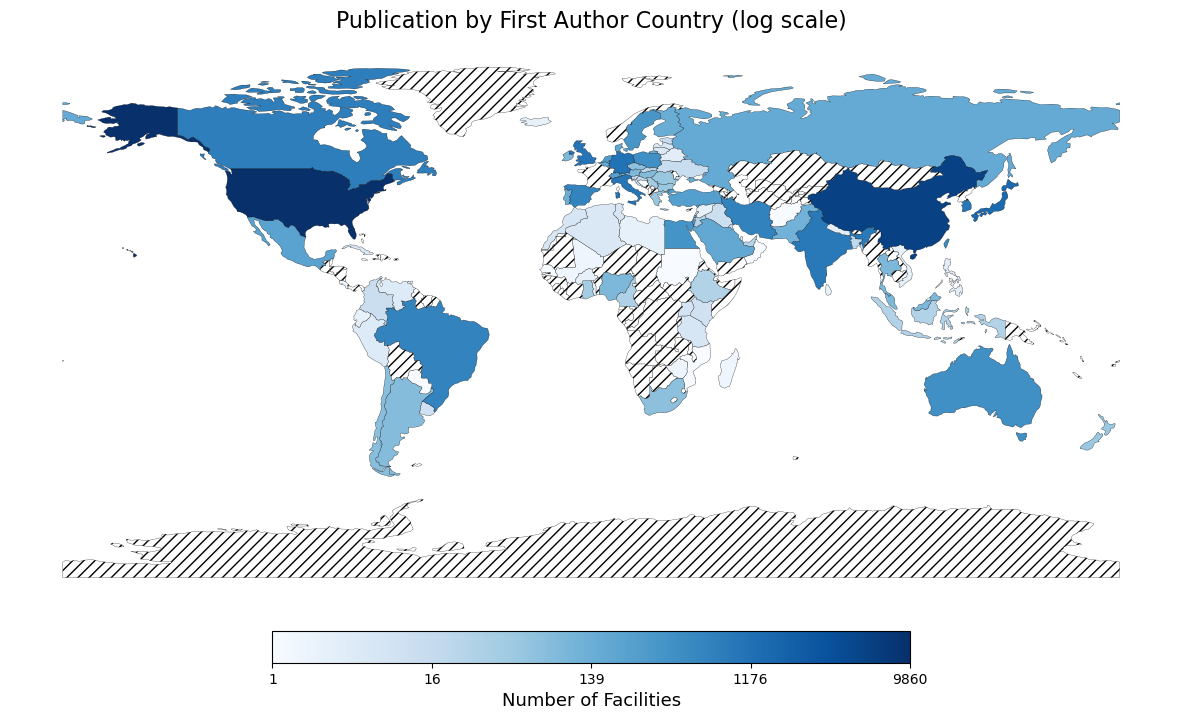

In [68]:
WORLD_SHP = "./data/countries_viz/ne_110m_admin_0_countries.shp"  # update path if needed
OUT_PDF   = "viz/preclinical_studies_world_map.pdf"

df_filtered = df
# ----- 1) Count the number of facilities (or articles) per country -----
country_counts = (
    df_filtered["first_author_country"]
      .astype(str)
      .str.strip()
      .replace({"unlabeled": np.nan, "": np.nan})
      .dropna()
      .to_frame(name="first_author_country")
)

country_counts["first_author_country"] = (
    country_counts["first_author_country"]
      .str.strip(" .;:,")                     # <— remove trailing punctuation
      .str.replace(r"\s+", " ", regex=True)   # collapse weird spacing
)

# Re-aggregate after cleaning
country_counts = (country_counts["first_author_country"]
                  .value_counts()
                  .rename_axis("first_author_country")
                  .reset_index(name="count"))

# ----- 2) Map display names -> ISO3 so we can merge robustly -----
def to_iso3(name: str):
    if not isinstance(name, str) or not name.strip():
        return None
    name = name.strip()
    try:
        return pycountry.countries.lookup(name).alpha_3
    except Exception:
        pass
    fixes = {
        # Common aliases
        "USA": "USA", "U.S.A.": "USA", "United States": "USA", "US": "USA", "U.S.": "USA",
        "UK": "GBR", "U.K.": "GBR", "England": "GBR", "Scotland": "GBR", "Wales": "GBR", "Northern Ireland": "GBR",
        "The Netherlands": "NLD", "Netherlands": "NLD",
        "Czech Republic": "CZE", "Russia": "RUS",
        "South Korea": "KOR", "Korea": "KOR", "Republic of Korea": "KOR", "North Korea": "PRK",
        "Ivory Coast": "CIV", "Côte d'Ivoire": "CIV",
        "Swaziland": "SWZ", "Eswatini": "SWZ",
        "Türkiye": "TUR", "Turkey": "TUR",
        "Hong Kong": "CHN", "Macau": "CHN", "Macao": "CHN",
        "Taiwan": "TWN",
        "Vietnam": "VNM", "Iran": "IRN",
        "East Timor": "TLS",
        "Micronesia": "FSM",
        "São Tomé and Príncipe": "STP", "Sao Tome and Principe": "STP",
        "Bolivia": "BOL", "Venezuela": "VEN", "Moldova": "MDA",
        "Syria": "SYR", "Laos": "LAO", "Brunei": "BRN", "Cape Verde": "CPV",
        "France":"FRA"
    }
    return fixes.get(name)

country_counts["iso3"] = country_counts["first_author_country"].map(to_iso3)

# Report anything that didn’t map (optional but handy)
unmatched = country_counts[country_counts["iso3"].isna()]["first_author_country"].tolist()
if unmatched:
    print("Unmatched country labels:", unmatched)

# Keep only rows we can place on a map
plot_counts = country_counts.dropna(subset=["iso3"]).copy()

# ----- 3) Load Natural Earth Admin 0 – Countries and normalize its ISO column -----
if not os.path.exists(WORLD_SHP):
    raise FileNotFoundError(f"World shapefile not found at {WORLD_SHP}. "
                            "Download 'ne_110m_admin_0_countries' from Natural Earth and update WORLD_SHP.")

world = gpd.read_file(WORLD_SHP)

# Normalize to a single 'iso3' column regardless of schema
if "iso_a3" in world.columns:
    world["iso3"] = world["iso_a3"]
elif "ISO_A3" in world.columns:
    world["iso3"] = world["ISO_A3"]
elif "ADM0_A3" in world.columns:
    world["iso3"] = world["ADM0_A3"]
else:
    raise ValueError(f"No ISO code column found in world layer. Columns: {world.columns.tolist()}")

# ----- 4) Merge counts onto the world layer -----
world = world.merge(plot_counts[["iso3", "count"]], how="left", on="iso3")

# Log-transform (for wide ranges)
world["log_count"] = np.log1p(world["count"].fillna(0))

# Treat zeros as NaN so they plot as “no data” (white)
world.loc[world["log_count"] == 0, "log_count"] = np.nan

# ----- 5) Plot -----
fig, ax = plt.subplots(1, 1, figsize=(15, 9))
world.plot(
    ax=ax,
    column="log_count",
    cmap="Blues",
    legend=False,
    edgecolor="black",
    linewidth=0.2,
    missing_kwds={"color": "white", "hatch": "///", "label": "No data"},
)

ax.set_axis_off()
ax.set_title("Publication by First Author Country (log scale)", fontsize=16, pad=10)

# Custom colorbar with original counts on ticks
vmin = np.nanmin(world["log_count"])
vmax = np.nanmax(world["log_count"])
norm = Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(cmap="Blues", norm=norm)
sm.set_array([])

cb = plt.colorbar(sm, ax=ax, orientation="horizontal", fraction=0.046, pad=0.04)
cb.set_label("Number of Facilities", fontsize=13)

# put 5 ticks spanning the log range, then label with expm1
tick_locs = np.linspace(vmin, vmax, num=5) if np.isfinite(vmin) and np.isfinite(vmax) else np.array([0])
cb.set_ticks(tick_locs)
cb.set_ticklabels((np.expm1(tick_locs)).round().astype(int))

# ----- 6) Save & show -----
os.makedirs(os.path.dirname(OUT_PDF), exist_ok=True)
plt.savefig(OUT_PDF, format="pdf", bbox_inches="tight", dpi=200)
print(f"Saved map → {OUT_PDF}")
plt.show()

In [69]:
mask_unlabeled = df["first_author_country"].isna() | (df["first_author_country"].astype(str).str.strip() == "unlabeled")
n_unlabeled = mask_unlabeled.sum()

print(f"Unlabeled first_author_country rows: {n_unlabeled} / {len(df)}")

Unlabeled first_author_country rows: 463 / 32762


In [70]:
selected_disease="all"

/var/folders/nd/2fzvhsh510gbt9x6z5pdb1gr0000gn/T/ipykernel_59591/70800855.py:105: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


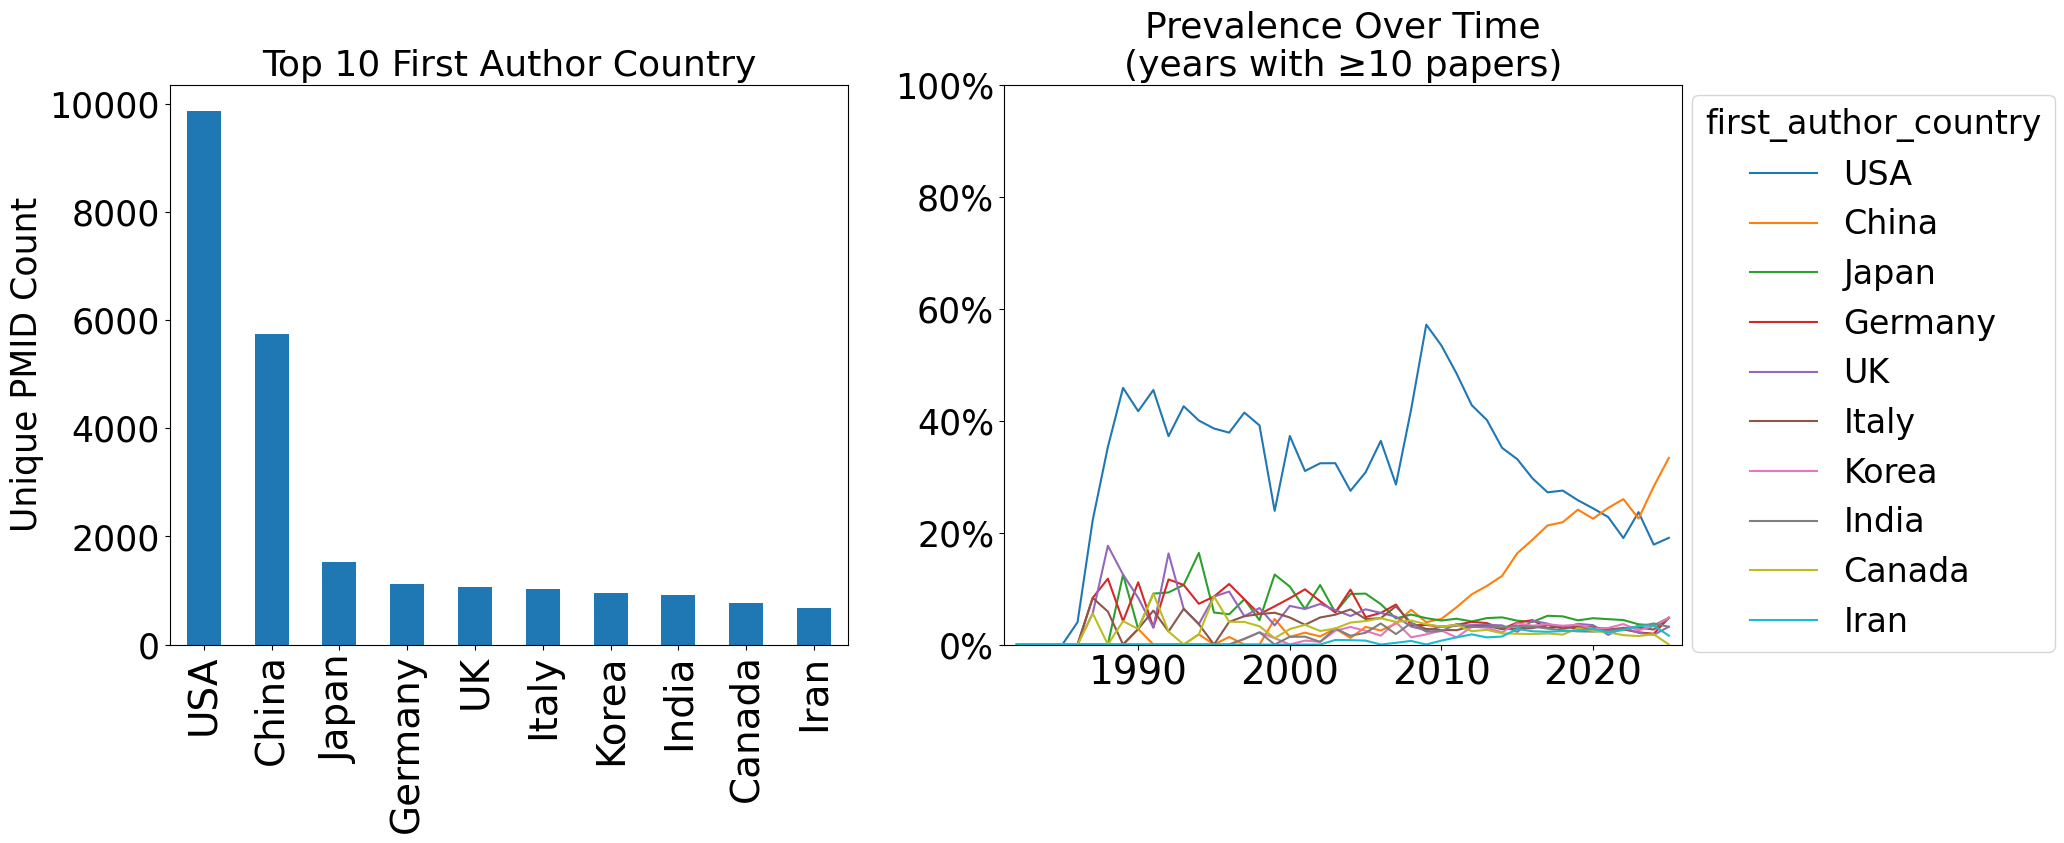

In [71]:
prevalence, top_yearly, yearly_totals = plot_counts_and_trends(df, "first_author_country", selected_disease="all")

## Trends: yes/no

In [77]:
def extract_unique_drugs(drug_series, min_length=4):
    all_drugs = []
    for entry in drug_series.dropna():
        drugs = [d.strip() for d in entry.split('|') if len(d.strip()) >= min_length]
        all_drugs.extend(drugs)
    return set(all_drugs)
    
# Separate approved and failed drug columns
approved_drugs = extract_unique_drugs(df[df['study_classification'] == 'approved']['drug'])
failed_drugs = extract_unique_drugs(df[df['study_classification'] == 'failed']['drug'])


In [79]:
len(failed_drugs), len(approved_drugs)

(26821, 549)

In [81]:
def count_drugs(entry, min_length=4):
    if pd.isna(entry):
        return 0
    return sum(1 for d in entry.split('|') if len(d.strip()) >= min_length)

# Add a column for number of drugs
df['drug_count'] = df['drug'].apply(count_drugs)

# Overall stats
overall_avg = df['drug_count'].mean()
overall_min = df['drug_count'].min()
overall_max = df['drug_count'].max()
overall_median = df['drug_count'].median()

# Stats per classification
stats_per_class = df.groupby('study_classification')['drug_count'].agg(['mean', 'median', 'min', 'max'])

print("Overall stats:")
print(f"Average: {overall_avg:.2f}")
print(f"Median: {overall_median}")
print(f"Min: {overall_min}")
print(f"Max: {overall_max}\n")

print("Stats per classification:")
print(stats_per_class)

Overall stats:
Average: 3.11
Median: 2.0
Min: 1
Max: 36

Stats per classification:
                          mean  median  min  max
study_classification                            
approved              2.720508     2.0    1   13
failed                3.120984     2.0    1   36


In [208]:
sampled = df.sample(n=50, random_state=42)

# Save to a new CSV
sampled.to_csv(f"validation/sampled_50_{selected_disease}.csv", index=False)

In [83]:

# Group by 'study_classification' and calculate totals
totals = df.groupby('study_classification')[binary_cols].sum()

# Also get total number of studies in each group
group_sizes = df['study_classification'].value_counts().sort_index()

# Calculate percentages
percentages = (totals.T / group_sizes).T * 100

# Combine into one summary DataFrame
summary = totals.astype(int).astype(str) + " (" + percentages.round(1).astype(str) + "%)"
summary.T

study_classification,approved,failed
tested_in_both_sexes,46 (8.3%),3247 (10.1%)
tested_in_multiple_strains,112 (20.3%),4705 (14.6%)
tested_in_multiple_species,57 (10.3%),3170 (9.8%)
tested_with_multiple_outcomes,402 (73.0%),21004 (65.2%)
rigor_blinding_binary,164 (29.8%),8293 (25.7%)
rigor_randomization_binary,161 (29.2%),12572 (39.0%)
rigor_welfare_binary,434 (78.8%),25478 (79.1%)


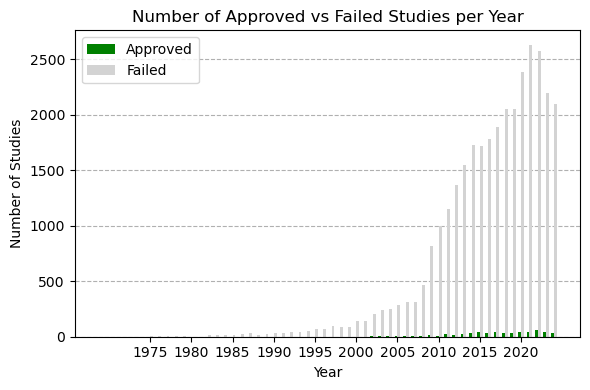

In [85]:
# Ensure 'year' is integer
df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')
df_clean = df[(df['year'] != 2025) & (df['year'].notna())]

# Count studies per year per classification
counts = df_clean.groupby(['year', 'study_classification']).size().reset_index(name='count')

# Pivot to get approved and failed as columns
pivot_counts = counts.pivot(index='year', columns='study_classification', values='count').fillna(0)
pivot_counts = pivot_counts.sort_index()
years = pivot_counts.index.astype(int)
width = 0.35  # bar width

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(years - width/2, pivot_counts.get('approved', 0), width=width, label='Approved', color='green', zorder=2)
ax.bar(years + width/2, pivot_counts.get('failed', 0), width=width, label='Failed', color='lightgrey', zorder=2)

# Dashed grid behind bars
ax.grid(True, axis='y', linestyle='--', zorder=0)

ax.set_xlabel('Year')
ax.set_ylabel('Number of Studies')
ax.set_title('Number of Approved vs Failed Studies per Year')

# Show only every 5th year on x-axis
ax.set_xticks([y for y in years if y % 5 == 0])
ax.set_xticklabels([y for y in years if y % 5 == 0])

ax.legend()
plt.tight_layout()
plt.show()

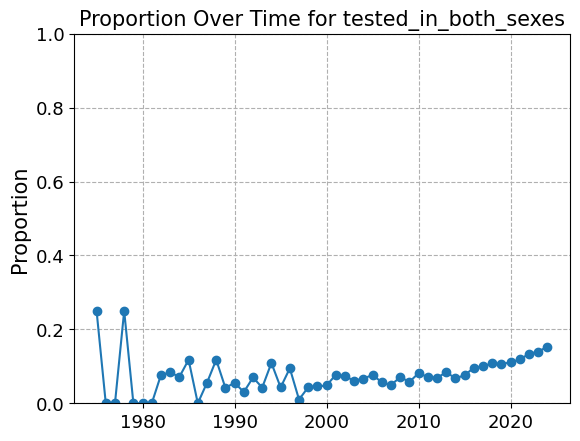

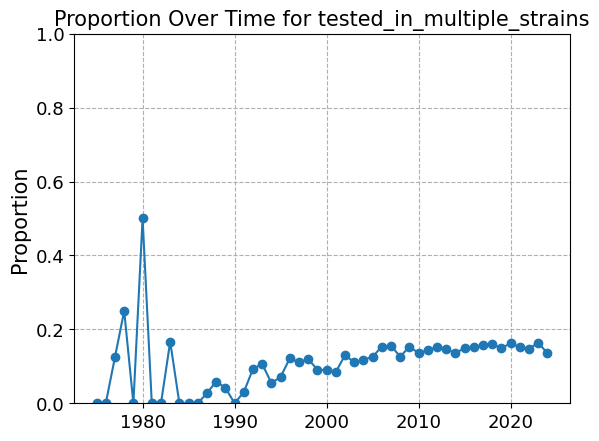

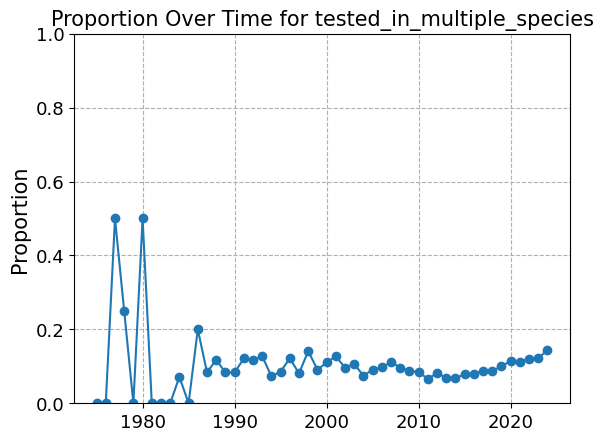

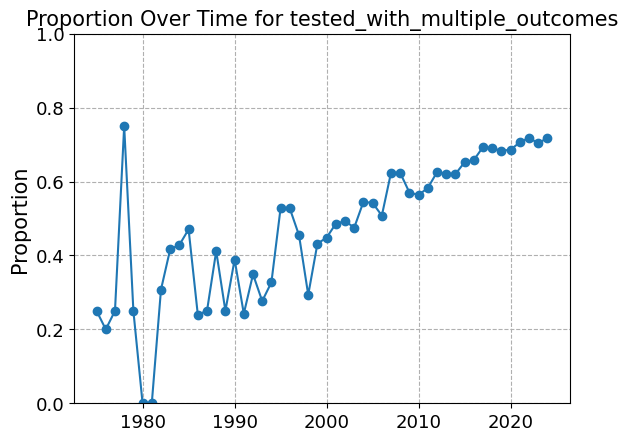

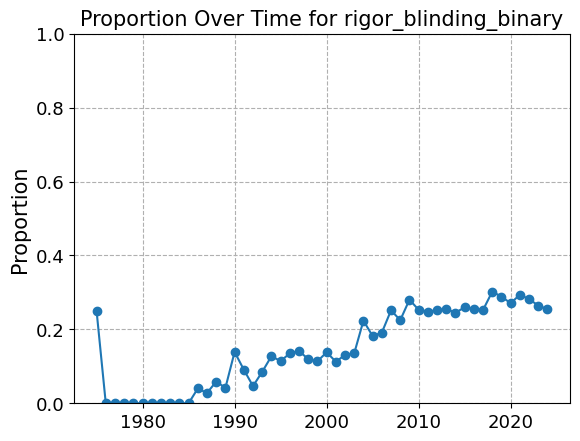

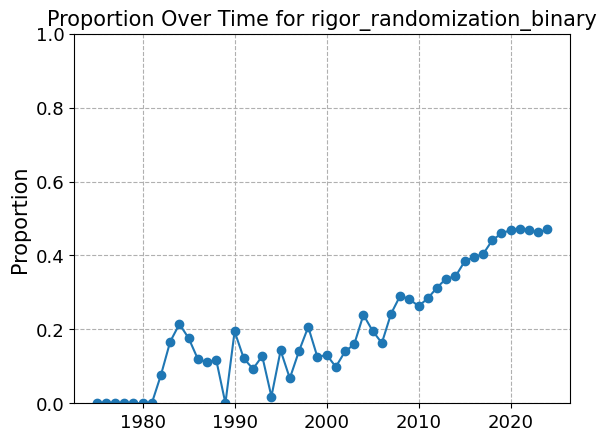

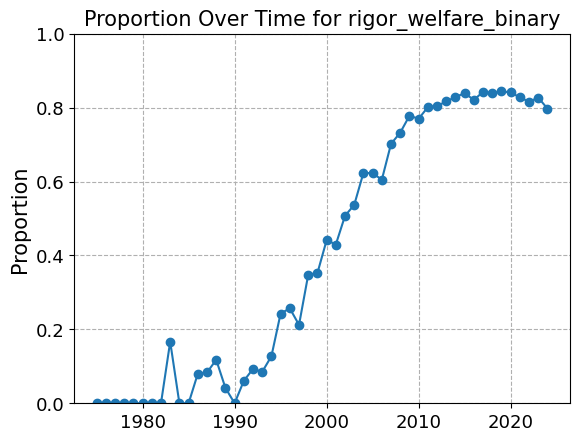

In [87]:
df['year'] = pd.to_numeric(df['year'], errors='coerce')

# Drop rows with missing year and exclude year 2025
df_clean = df.dropna(subset=['year'])
df_clean = df_clean[df_clean['year'] != 2025]

# Filter out years with only one study
year_counts = df_clean['year'].value_counts()
valid_years = year_counts[year_counts > 1].index
df_clean = df_clean[df_clean['year'].isin(valid_years)]

# Group by year and calculate mean (proportion of 1s)
proportion_by_year = df_clean.groupby('year')[binary_cols].mean().reset_index()

# Plot each binary column over time
for col in binary_cols:
    plt.figure()
    plt.plot(proportion_by_year['year'], proportion_by_year[col], marker='o')
    plt.title(f'Proportion Over Time for {col}', fontsize=15)
    plt.xlabel('', fontsize=15)
    plt.ylabel('Proportion', fontsize=15)
    plt.ylim(0, 1)
    plt.grid(True, linestyle='--')
    plt.tick_params(axis='both', labelsize=13)
    plt.savefig(f"./viz/{selected_disease}_{col}_over_time.png")
    plt.show()

## Trends: values

In [90]:
preclinical_df = preclinical_df_raw.copy()

In [92]:
preclinical_df.shape

(32762, 29)

/var/folders/nd/2fzvhsh510gbt9x6z5pdb1gr0000gn/T/ipykernel_59591/70800855.py:105: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


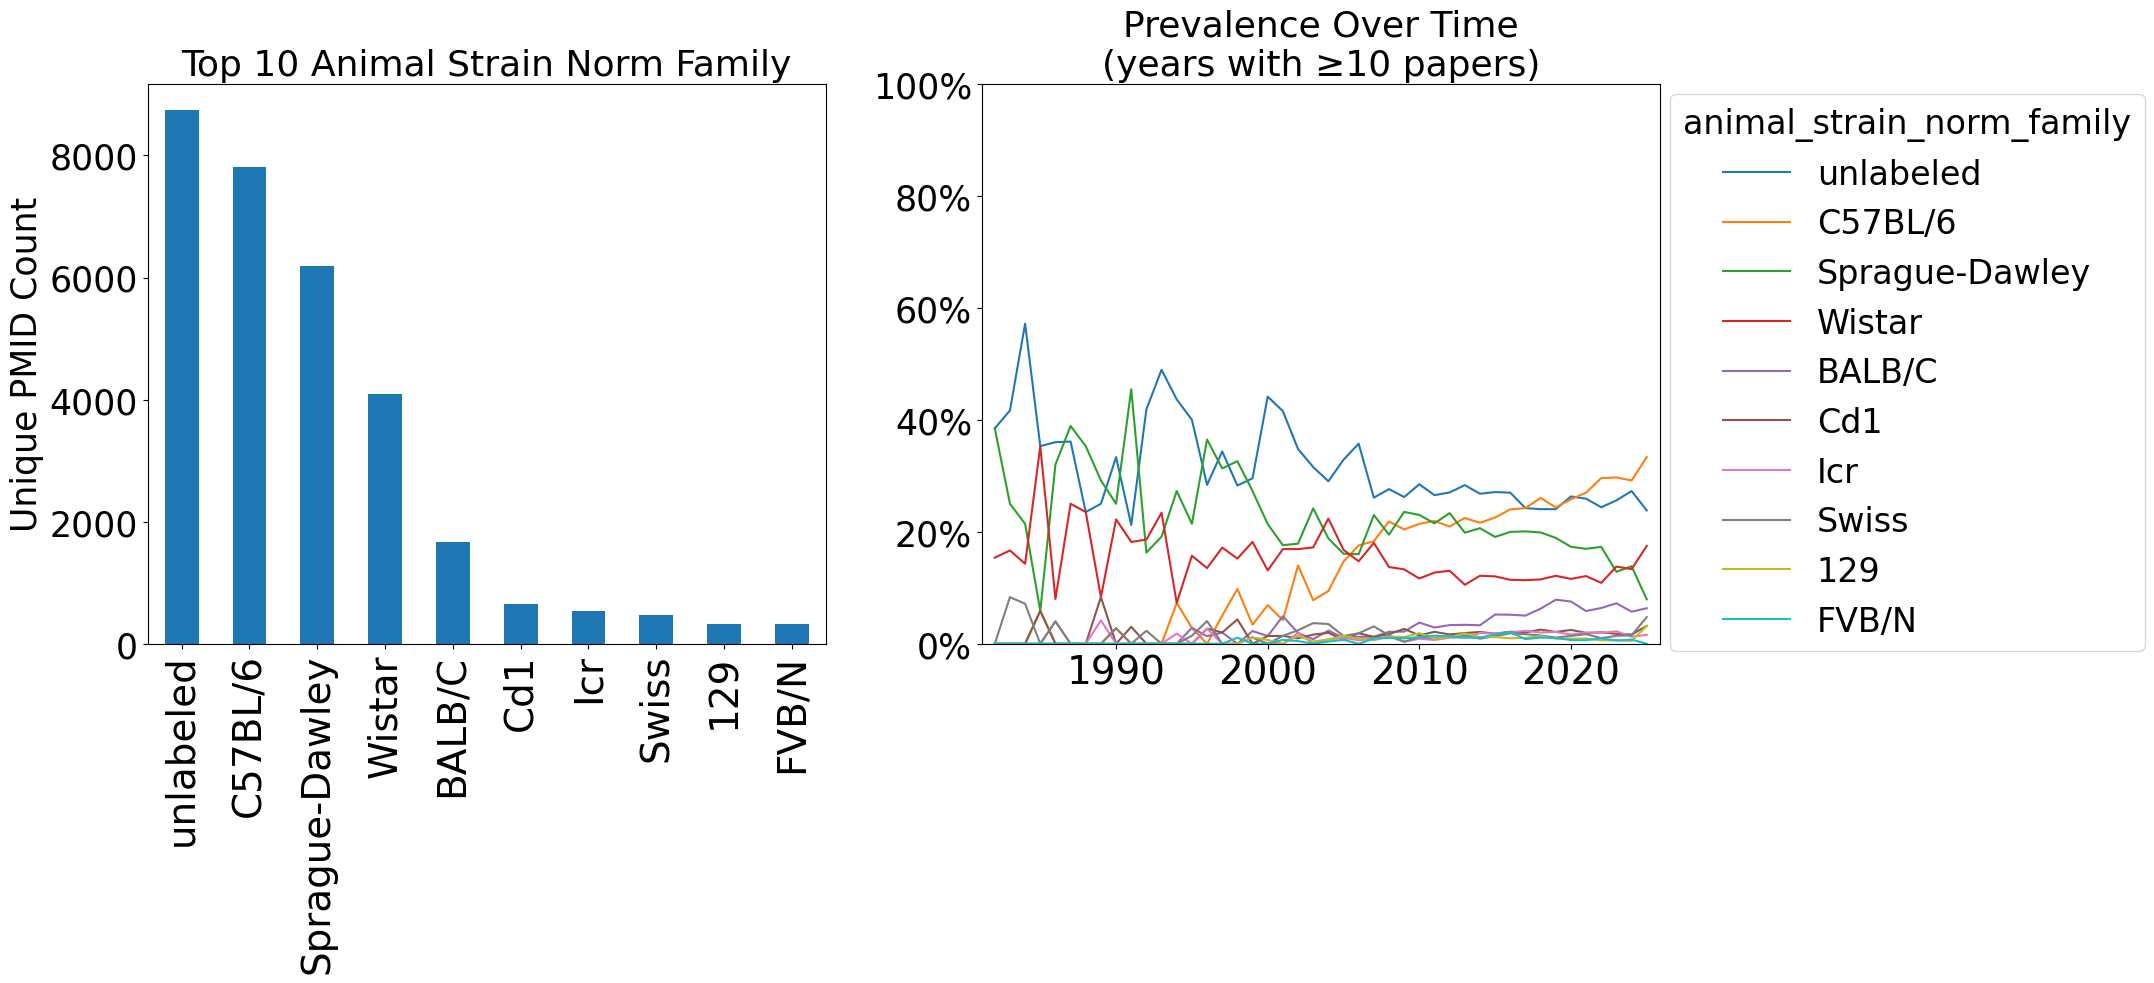

In [94]:
prevalence, top_yearly, yearly_totals = plot_counts_and_trends(preclinical_df, "animal_strain_norm_family", selected_disease)

/var/folders/nd/2fzvhsh510gbt9x6z5pdb1gr0000gn/T/ipykernel_59591/70800855.py:105: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


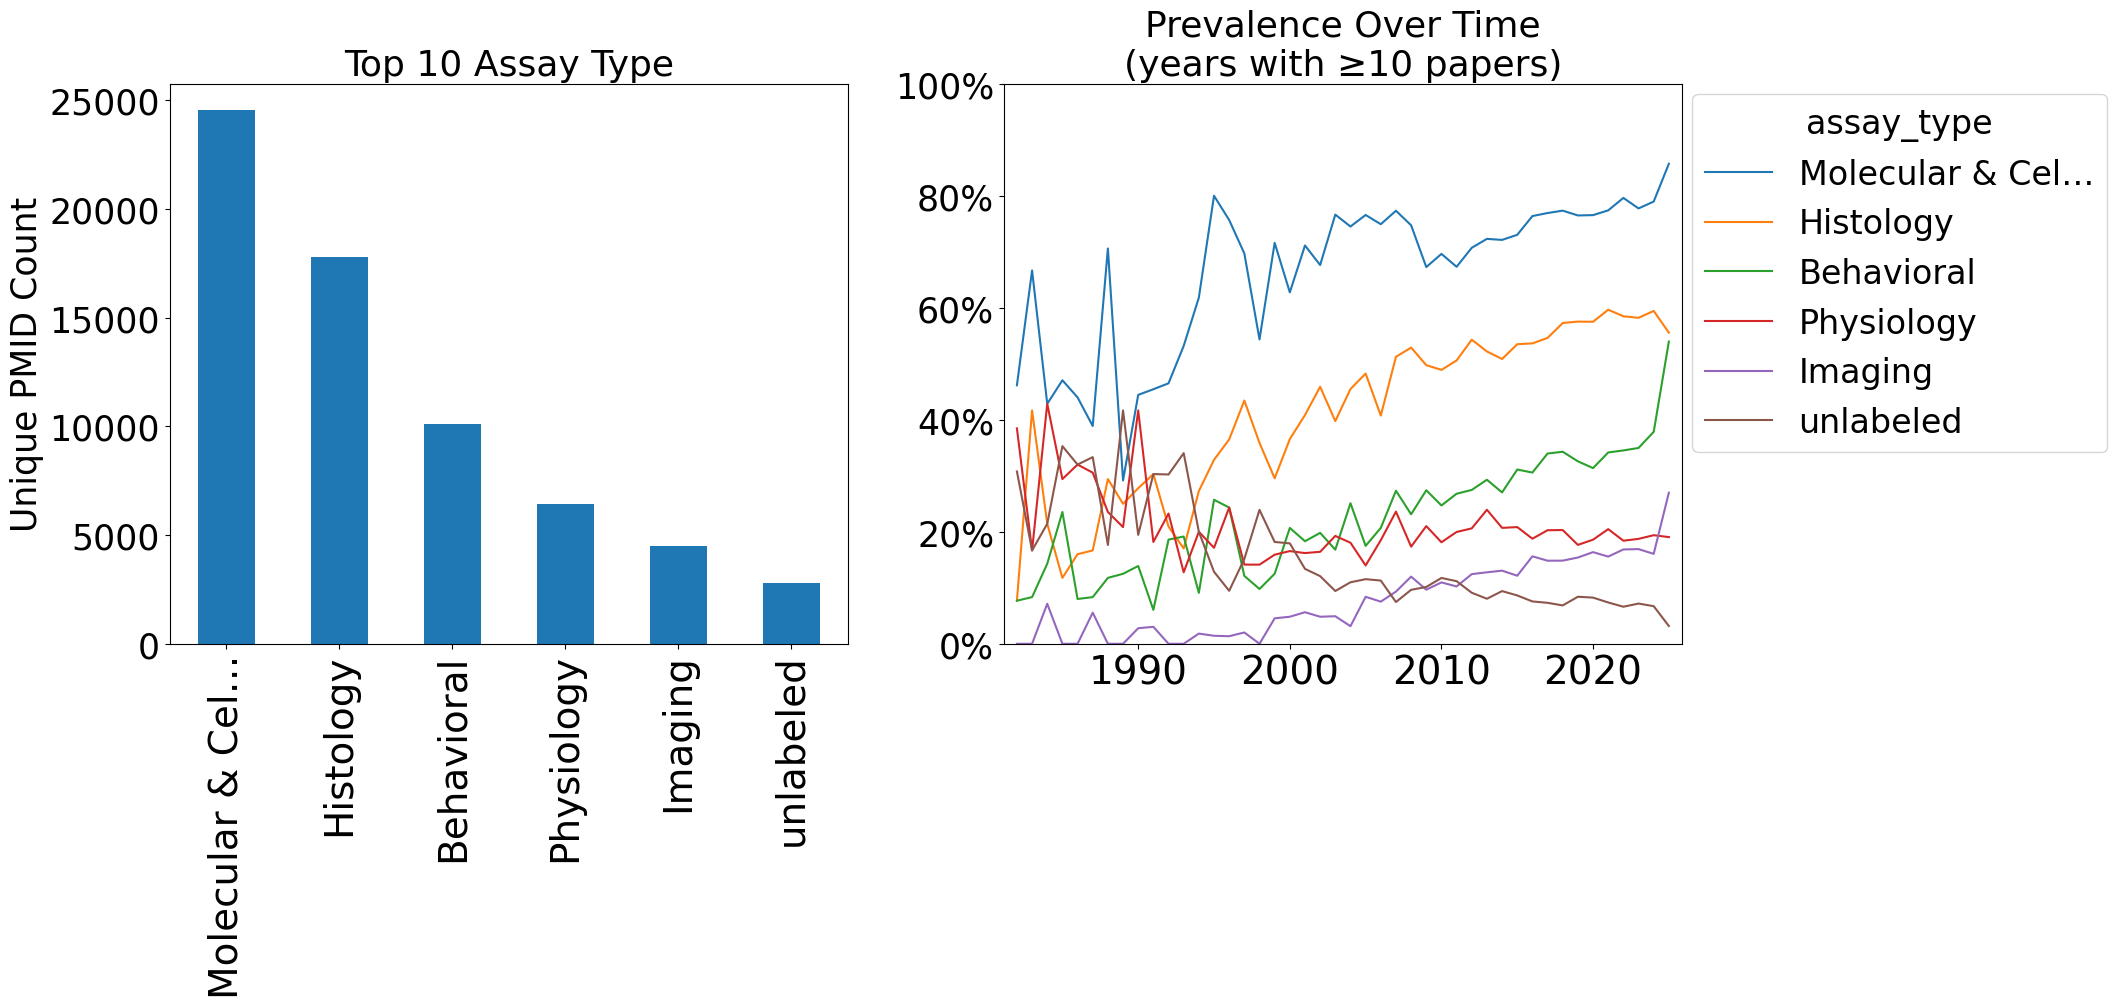

In [96]:
prevalence, top_yearly, yearly_totals = plot_counts_and_trends(preclinical_df, "assay_type", selected_disease)

/var/folders/nd/2fzvhsh510gbt9x6z5pdb1gr0000gn/T/ipykernel_59591/70800855.py:105: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


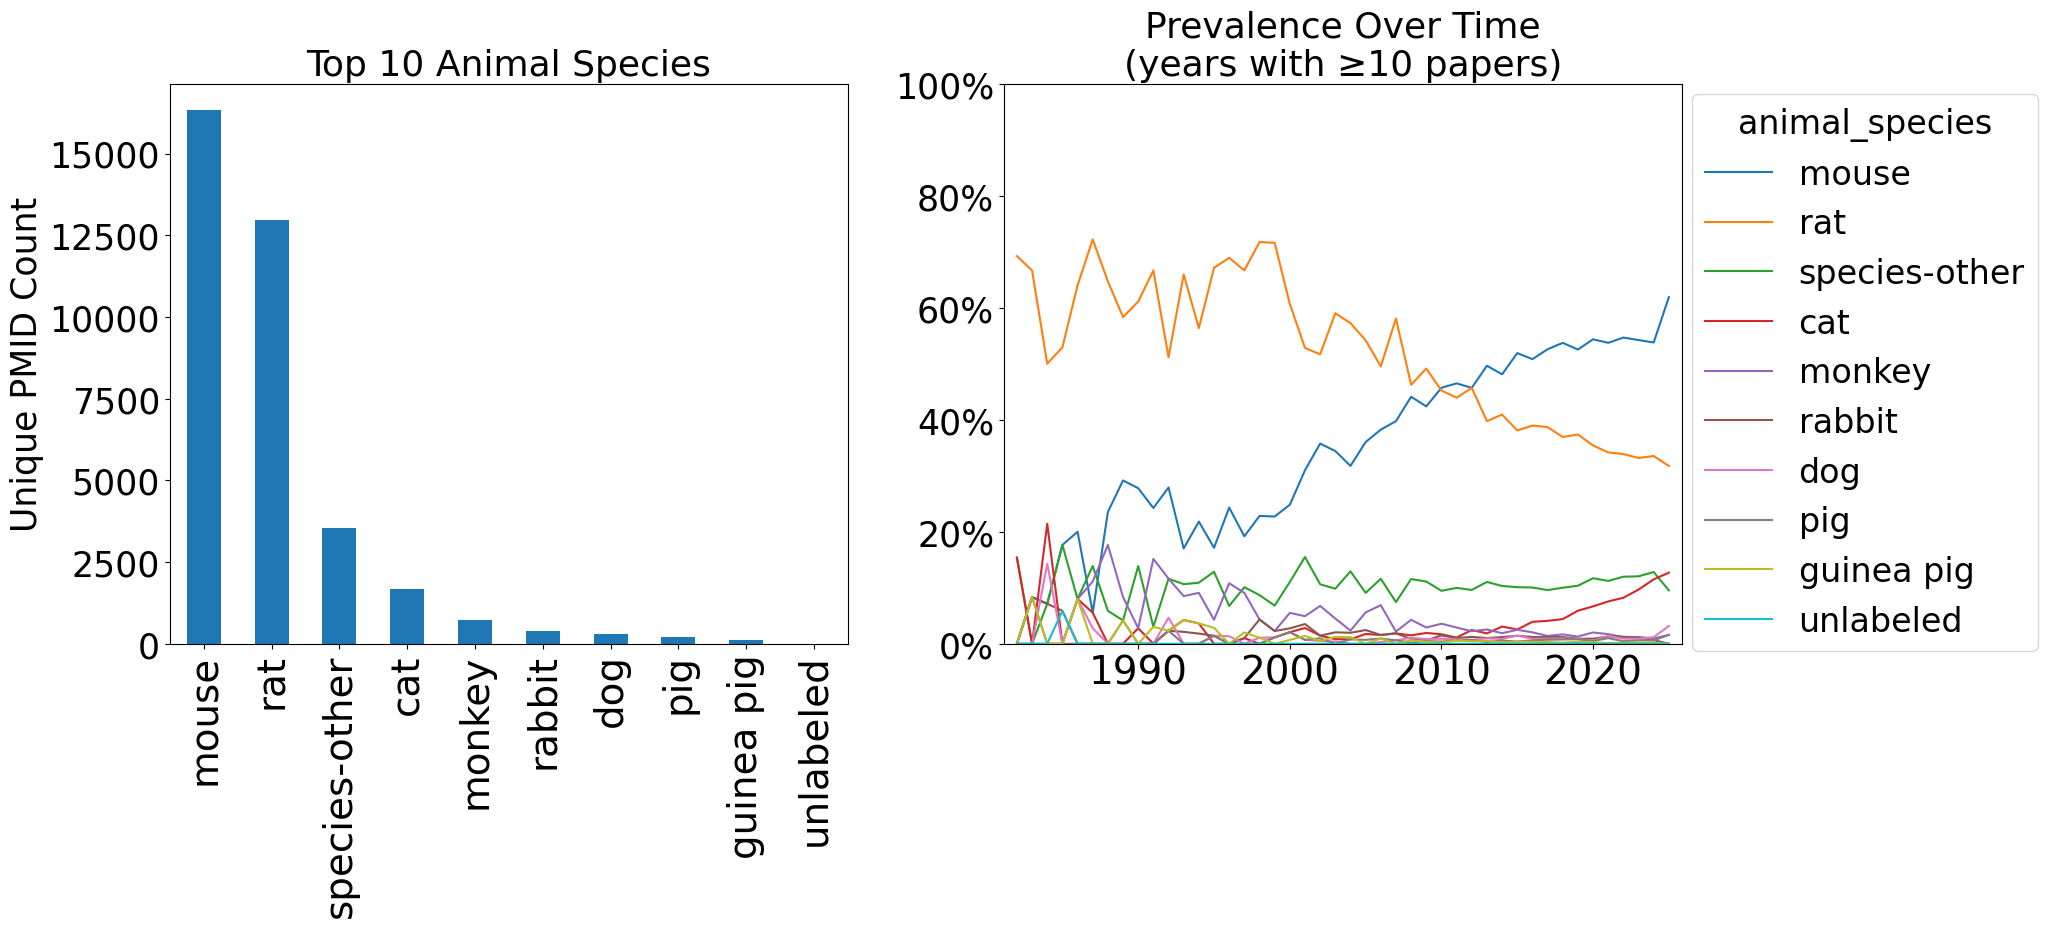

In [97]:
prevalence, top_yearly, yearly_totals = plot_counts_and_trends(preclinical_df, "animal_species", selected_disease)

In [100]:
45.5 + 75.4 + 10.8 + 31.2 + 6.6

169.5

In [102]:
preclinical_df["animal_sex"] = preclinical_df["animal_sex"].apply(lambda x: x.replace("sex-not-reported", "sex-missing"))

/var/folders/nd/2fzvhsh510gbt9x6z5pdb1gr0000gn/T/ipykernel_59591/70800855.py:105: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


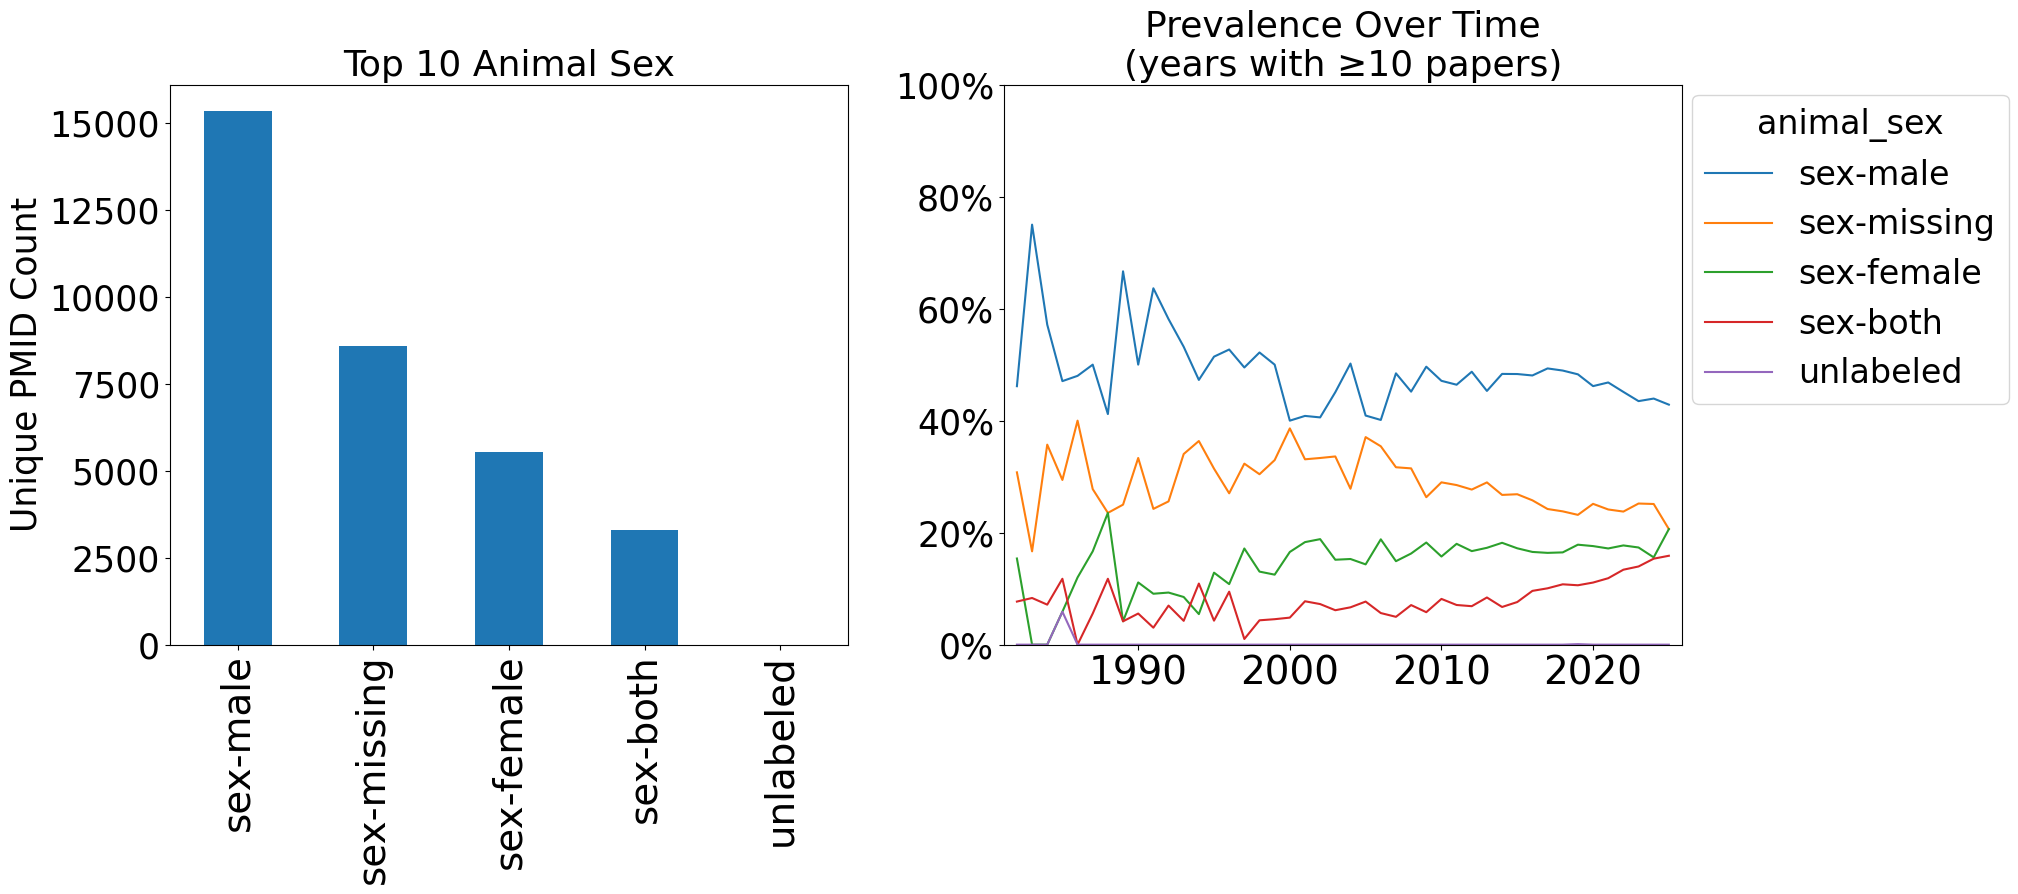

In [104]:
prevalence, top_yearly, yearly_totals = plot_counts_and_trends(preclinical_df, "animal_sex", selected_disease, max_label_length=16)

In [106]:
conditions_col_to_use = "disease"
drugs_col_to_use = "drug"

preclinical_df[conditions_col_to_use] = preclinical_df[conditions_col_to_use].str.split("|")
preclinical_df = preclinical_df.explode(conditions_col_to_use, ignore_index=True)
preclinical_df[conditions_col_to_use] = preclinical_df[conditions_col_to_use].str.strip().str.title()

preclinical_df[drugs_col_to_use] = preclinical_df[drugs_col_to_use].str.split("|")
preclinical_df = preclinical_df.explode(drugs_col_to_use, ignore_index=True)
preclinical_df[drugs_col_to_use] = preclinical_df[drugs_col_to_use].str.strip().str.title()


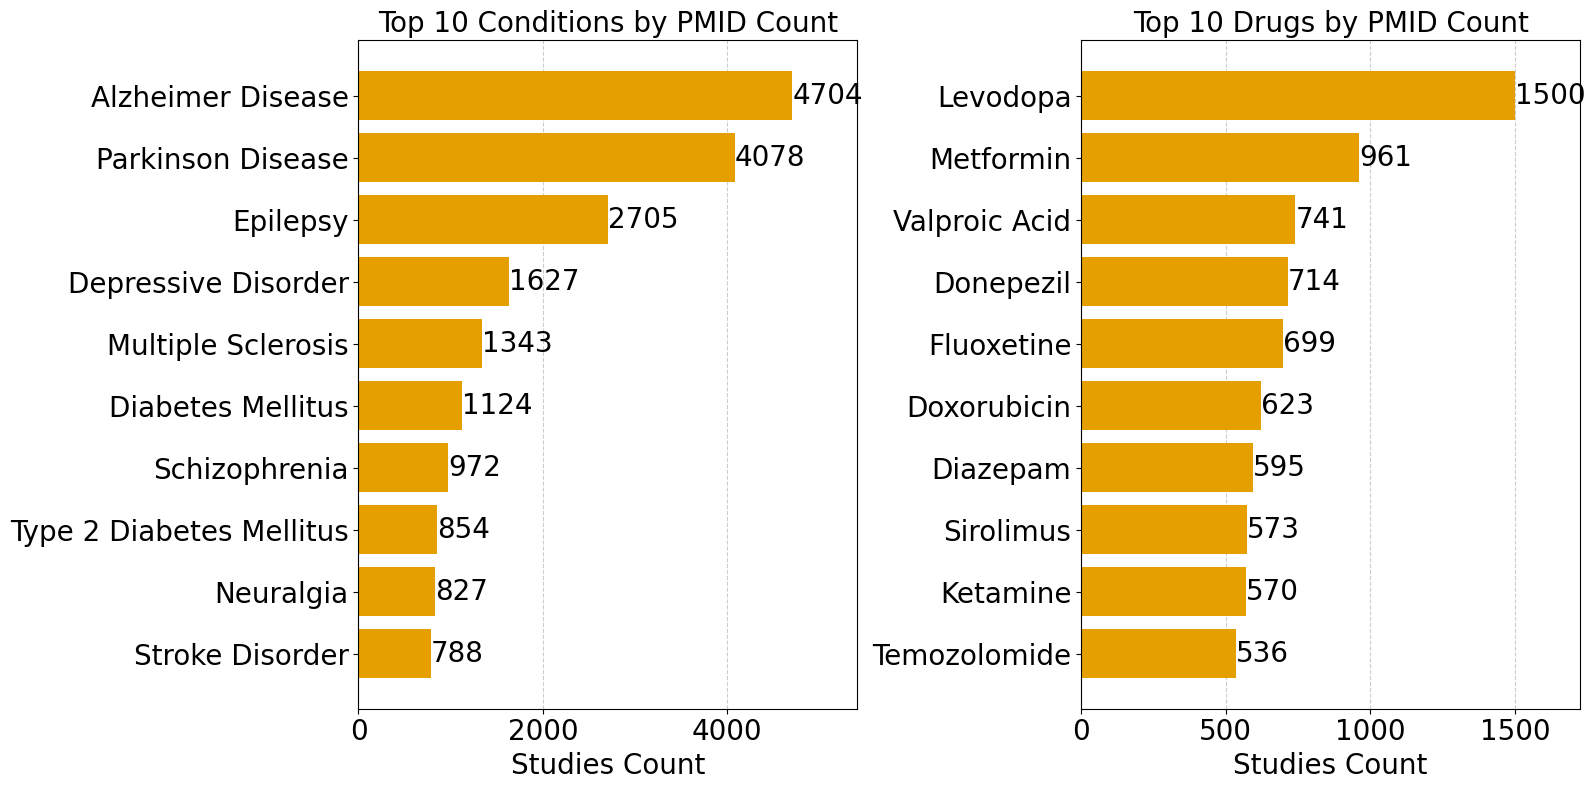

In [108]:
plot_top_entities_side_by_side(preclinical_df, 'PMID', conditions_col_to_use, drugs_col_to_use, save=True, save_path="viz/", top_n=10, color_code='#E69F00', viz_name_suffix='preclinical_all', save_to="png", custom_fontsize=20)

In [110]:
preclinical_df.shape

(195736, 29)

In [112]:
preclinical_df[['PMID','drug','disease']].head()

,PMID,drug,disease
0,31733940,Minocycline,Cognitive Disorder
1,31734290,Perampanel,Glioma-Associated Seizures
2,31734290,Perampanel,Glioma-Associated Seizures
3,31734290,Perampanel,Glioma-Associated Seizures
4,31734290,Perampanel,Glioma-Associated Epilepsy


In [114]:
len(approved_dmts_canonical)

17

In [116]:
def get_best_match(name, choices, threshold=0.95):
    best_score, best_choice = 0, None
    for choice in choices:
        score = SequenceMatcher(None, name.lower(), choice.lower()).ratio()
        if score > best_score:
            best_score, best_choice = score, choice
    return best_choice if best_score >= threshold else None

# — assume `df` is your full DataFrame with columns ["PMID","drug","disease"] —

# 1) Tag each row by whether its `drug` fuzzy-matches an approved DMT
preclinical_df['matched_approved'] = preclinical_df['drug'].apply(lambda d: get_best_match(d, approved_dmts_canonical))

# 2) Pull out all PMIDs that *do* have at least one approved match
approved_pmids = preclinical_df.loc[preclinical_df['matched_approved'].notnull(), 'PMID'].unique()

# 3) Build your two DataFrames
approved_df = preclinical_df[preclinical_df['PMID'].isin(approved_pmids)].copy()
failed_df   = preclinical_df[~preclinical_df['PMID'].isin(approved_pmids)].copy()

In [117]:
#plot_top_entities_side_by_side(approved_df, 'PMID', conditions_col_to_use, drugs_col_to_use, save=False)

In [118]:
#plot_top_entities_side_by_side(failed_df, 'PMID', conditions_col_to_use, drugs_col_to_use, save=False)

In [119]:
def plot_unique_pmid_counts(df, pmid_col, report_col):
    """
    Plots the count of unique PMIDs for each unique value in a specified report column,
    with percentage labels on top of the bars.

    Parameters:
    - df: pandas DataFrame containing the data.
    - pmid_col: name of the column with PMID identifiers.
    - report_col: name of the column whose unique values will be counted.

    Returns:
    - None: displays a bar chart.
    """
    # Calculate unique PMID counts per report value
    counts = df.groupby(report_col)[pmid_col].nunique()
    
    # Sort counts for better visualization
    counts = counts.sort_values(ascending=False)
    
    # Compute percentages
    total = counts.sum()
    percentages = (counts / total * 100).round(1)

    # Plot
    fig, ax = plt.subplots()
    bars = counts.plot(kind='bar', ax=ax)

    ax.set_xlabel(report_col)
    ax.set_ylabel(f'Unique {pmid_col} Count')
    ax.set_title(f'Unique {pmid_col} by {report_col}')
    plt.xticks(rotation=45, ha='right')

    # Annotate with percentages
    for i, (count, pct) in enumerate(zip(counts, percentages)):
        ax.text(i, count + total * 0.01, f'{pct}%', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()


In [120]:
def plot_pmid_counts_over_year(
        df,
        pmid_col: str = "PMID",
        year_col: str = "year",
        *,
        dropna: bool = True,
        ax=None
    ):
    """
    Bar-plot the number of unique PMIDs observed in each publication year.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain `pmid_col` and `year_col`.
    pmid_col : str, default "PMID"
        Column holding PubMed IDs (or any identifier to count).
    year_col : str, default "year"
        Column holding publication year.
    dropna : bool, default True
        If True, rows whose year cannot be coerced to an int are removed.
        If False, those rows are kept with a nullable integer ('Int64') type.
    ax : matplotlib.axes.Axes, optional
        Supply an existing axis to add the plot to.

    Returns
    -------
    matplotlib.axes.Axes
        The axis with the rendered bar plot.
    """
    # Coerce year values to numeric first; anything unparseable → NaN
    year_series = pd.to_numeric(df[year_col], errors="coerce")

    if dropna:
        df = df.loc[year_series.notna()].copy()
        df[year_col] = year_series.dropna().astype(int)
    else:
        df = df.copy()
        df[year_col] = year_series.astype("Int64")   # pandas nullable integer

    # Aggregate: count *unique* PMIDs per year
    counts = (
        df.groupby(year_col, sort=True)[pmid_col]
          .nunique()          # or .size() if counting rows instead of unique IDs
    )

    # Plot
    if ax is None:
        _, ax = plt.subplots()
    counts.plot(kind="bar", ax=ax)       # simple, readable bar chart
    ax.set_xlabel("Publication year")
    ax.set_ylabel("Unique PMID count")
    ax.set_title("PMID records per year")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()

    plt.show()
    

In [121]:
approved_df.columns

Index(['PMID', 'year', 'journal_name', 'publication_type', 'title',
       'Unnamed: 0', 'raw_disease', 'raw_drug', 'linkbert_mapped_conditions',
       'linkbert_mapped_drugs', 'disease', 'disease_mondo_termid', 'drug',
       'drug_umls_termid', 'animal_sex', 'animal_species', 'animal_age_class',
       'animal_age', 'rigor_blinding', 'rigor_randomization', 'rigor_welfare',
       'assay_type', 'animal_strain', 'animal_number', 'animal_strain_norm',
       'animal_strain_norm_family', 'first_author_affiliation',
       'first_author_country', 'first_author_geolocation', 'matched_approved'],
      dtype='object')

In [122]:
approved_df.PMID.nunique(), failed_df.PMID.nunique()

(540, 32222)

In [375]:
import requests
import pandas as pd

def first_fda_approval_details(drug):
    q = f'openfda.generic_name:"{drug}"'
    try:
        resp = requests.get(
            "https://api.fda.gov/drug/drugsfda.json",
            params={"search": q, "limit": 100}
        )
        resp.raise_for_status()
    except requests.HTTPError as e:
        if resp.status_code == 404:
            return None
        else:
            raise

    records = resp.json().get("results", [])

    orig_subs = []
    for rec in records:
        for sub in rec.get("submissions", []):
            if sub.get("submission_type") in ("ORIG", "NDA", "BLA"):
                date = pd.to_datetime(sub["submission_status_date"],
                                      format="%Y%m%d",
                                      errors="coerce")
                if pd.notna(date):
                    orig_subs.append({
                        "date": date,
                        "submission": sub,
                        "record": rec
                    })

    if not orig_subs:
        return None

    first = min(orig_subs, key=lambda x: x["date"])
    sub = first["submission"]
    rec = first["record"]
    openfda = rec.get("openfda", {})

    return {
        "generic_name": drug,
        "sponsor_name": rec.get("sponsor_name"),
        "application_number": rec.get("application_number"),
        "submission_type": sub.get("submission_type"),
        "submission_number": sub.get("submission_number"),
        "approval_date": first["date"],
        "indication": rec.get("products", [{}])[0].get("indication"),
        "pharm_class_cs": openfda.get("pharm_class_cs"),
        "pharm_class_epc": openfda.get("pharm_class_epc"),
        "pharm_class_pe": openfda.get("pharm_class_pe"),
        "pharm_class_moa": openfda.get("pharm_class_moa")
    }


In [385]:
details = first_fda_approval_details("Donepezil")
print(details)

{'generic_name': 'Donepezil', 'sponsor_name': 'EISAI INC', 'application_number': 'NDA020690', 'submission_type': 'ORIG', 'submission_number': '1', 'approval_date': Timestamp('1996-11-25 00:00:00'), 'indication': None, 'pharm_class_cs': None, 'pharm_class_epc': None, 'pharm_class_pe': None, 'pharm_class_moa': None}


In [399]:
details = first_fda_approval_details("Aducanumab")
print(details)

None


In [378]:
approved_dmts_canonical, approved_dmts

(['Tacrine',
  'donepezil',
  'Rivastigmine',
  'huperzine A',
  'Galantamine',
  'Memantine',
  'aducanumab',
  'lecanemab',
  'GV-971'],
 ['Tacrine',
  'donepezil',
  'Rivastigmine',
  'huperzine A',
  'Galantamine',
  'Memantine',
  'aducanumab',
  'lecanemab',
  'GV-971'])

In [393]:
drug_years = {}
pharm_class_epc = {}
pharm_class_moa = {}

for drug, canonical_drug_name in zip(approved_dmts, approved_dmts_canonical):
    details = first_fda_approval_details(drug)
    #print(drug, details)

    # Approval year
    approval_date = details.get("approval_date") if details else None
    drug_years[canonical_drug_name] = approval_date.year if approval_date else None

    # Pharmacologic class EPC
    epc = details.get("pharm_class_epc") if details else None
    pharm_class_epc[canonical_drug_name] = epc

    # Pharmacologic class MoA
    moa = details.get("pharm_class_moa") if details else None
    pharm_class_moa[canonical_drug_name] = moa

In [395]:
print(drug_years)

{'Tacrine': None, 'donepezil': 1996, 'Rivastigmine': 2007, 'huperzine A': None, 'Galantamine': 2009, 'Memantine': 2003, 'aducanumab': None, 'lecanemab': 2023, 'GV-971': None}


In [401]:
USER_AGENT = (
    "Mozilla/5.0 (compatible; FDAYearScraper/1.0; +your-email-or-repo)"
)

# ----------------------------------------------------------------------
# Low-level page fetcher  →  integer year | None
# ----------------------------------------------------------------------
def _year_from_history_page(slug: str, session: requests.Session) -> int | None:
    """
    Try https://www.drugs.com/history/<slug>.html and pull 'First approved <YEAR>'
    Returns the int YEAR or None if not found / 404 / parse fail.
    """
    url = f"https://www.drugs.com/history/{slug}.html"
    try:
        r = session.get(url, headers={"User-Agent": USER_AGENT}, timeout=(5, 15))
        if r.status_code == 404:           # saves a soup parse if the page is absent
            return None
        r.raise_for_status()
    except requests.RequestException:
        return None                        # network error, SSL issue, etc.

    soup = BeautifulSoup(r.text, "html.parser")
    node = soup.find(string=re.compile(r"First approved", re.I))
    if not node:
        return None

    m = re.search(r"\b(\d{4})\b", node)
    return int(m.group(1)) if m else None


# ----------------------------------------------------------------------
# Heuristic slug generator  (very lightweight “slugify”)
# e.g. "Fumarate, Dimethyl" → ["fumarate-dimethyl", "dimethyl-fumarate"]
# ----------------------------------------------------------------------
def _candidate_slugs(drug_name: str) -> list[str]:
    # basic alnum-only “words”
    words = re.sub(r"[^0-9a-zA-Z]+", " ", drug_name).lower().split()
    slugs = ["-".join(words)]

    # if original name had a comma, also try reversed word order
    if "," in drug_name:
        slugs.append("-".join(reversed(words)))

    # de-duplicate while preserving order
    return list(dict.fromkeys(slugs))


# ----------------------------------------------------------------------
# Public helper
# ----------------------------------------------------------------------
def fill_missing_approval_years(data: dict[str, int | None],
                                delay: float = 1.0) -> dict[str, int | None]:
    """
    Mutates and returns `data`, filling any None entries with the scraped year
    (or leaving None if the page/year is not found).
    `delay` pauses N seconds between hits to be polite.
    """
    session = requests.Session()

    for drug, yr in data.items():
        if yr is not None:
            continue                      # already have a year

        for slug in _candidate_slugs(drug):
            got = _year_from_history_page(slug, session)
            if got:
                data[drug] = got
                break                     # stop trying other slugs

        time.sleep(delay)                 # throttle

    return data

drug_years = fill_missing_approval_years(drug_years)


In [403]:
drug_years

{'Tacrine': None,
 'donepezil': 1996,
 'Rivastigmine': 2007,
 'huperzine A': None,
 'Galantamine': 2009,
 'Memantine': 2003,
 'aducanumab': 2021,
 'lecanemab': 2023,
 'GV-971': None}

In [405]:
pharm_class_moa

{'Tacrine': None,
 'donepezil': None,
 'Rivastigmine': ['Cholinesterase Inhibitors [MoA]'],
 'huperzine A': None,
 'Galantamine': None,
 'Memantine': None,
 'aducanumab': None,
 'lecanemab': ['Amyloid Beta-directed Antibody Interactions [MoA]'],
 'GV-971': None}

In [407]:
pharm_class_epc

{'Tacrine': None,
 'donepezil': None,
 'Rivastigmine': ['Cholinesterase Inhibitor [EPC]'],
 'huperzine A': None,
 'Galantamine': None,
 'Memantine': None,
 'aducanumab': None,
 'lecanemab': ['Amyloid Beta-directed Antibody [EPC]'],
 'GV-971': None}

In [409]:
approved_df[['PMID','drug','year']]

,PMID,drug,year
4,31739000,Rivastigmine,2020.0
25,31308798,Memantine,2019.0
26,31308798,non-competitive n-methyl-d-aspartate receptor ...,2019.0
27,31309074,Rivastigmine,2019.0
28,31309074,Rivastigmine,2019.0
...,...,...,...
24531,31499090,Rivastigmine,2019.0
24532,31499090,reversible inhibitor of cholinesterase,2019.0
24540,19308922,Tacrine,2009.0
24541,19308922,Melatonin,2009.0


In [411]:
import matplotlib.ticker as ticker       # add this with the other imports

# --- fuzzy match helper -------------------------------------------------
def fuzzy_filter(df, target, threshold=0.9):
    """Return rows whose 'drug' name is ≥ `threshold` similar to `target`."""
    def sim(a, b): return SequenceMatcher(None, a.lower(), b.lower()).ratio()
    return df[df["drug"].apply(lambda x: sim(x, target) >= threshold)].copy()

# --- main plotting helper ----------------------------------------------
def plot_drug_studies(drug, approval_year, df,
                      threshold=0.9, *, bubble=True, scale=40):
    """
    • bubble=True  → one bubble per YEAR, size ∝ #studies,
      with the count printed in its centre.
    • bubble=False → individual dots stacked vertically.
    """
    studies = fuzzy_filter(df, drug, threshold)
    if studies.empty:
        print(f"No studies found for '{drug}'."); return

    counts = (
        studies.groupby("year")["PMID"]
        .nunique()
        .reset_index(name="n")
    )

    plt.figure(figsize=(10, 2.8))

    if bubble:
        sizes = counts["n"] * scale
        plt.scatter(counts["year"], [0]*len(counts), s=sizes, alpha=.7)
        for yr, n in counts.itertuples(index=False):
            plt.text(yr, 0, n, ha="center", va="center", zorder=3, fontsize=8)
    else:
        xs, ys = [], []
        for yr, n in counts.itertuples(index=False):
            xs.extend([yr]*n)
            ys.extend(range(n))
        plt.scatter(xs, ys, alpha=.7)
        plt.yticks([])

    # approval marker
    plt.axvline(x=approval_year, linestyle="--")
    plt.scatter([approval_year], [0], marker="D")

    # integer x-axis
    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    plt.title(f"{drug} – studies by year (approval {approval_year})")
    plt.xlabel("Publication year")
    plt.yticks([])
    plt.tight_layout()
    plt.show()

In [415]:
drug_name = "Rivastigmine"

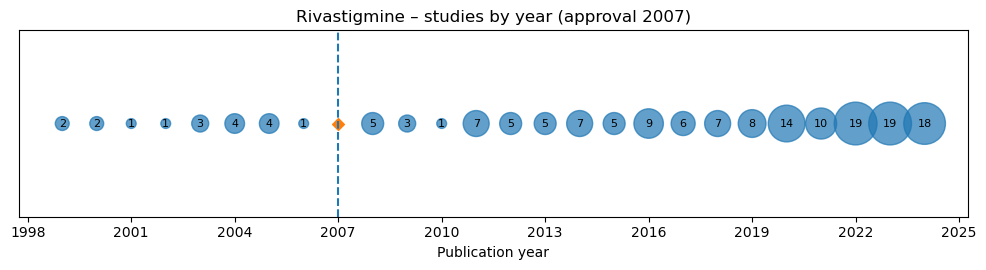

In [417]:
plot_drug_studies(drug_name,
                  drug_years[drug_name],
                  approved_df,
                  bubble=True,   # or False
                  scale=50)      # tweak bubble sizes if you like

In [419]:
#for drug, appr_year in drug_years.items():
  #  if appr_year is None:
   #     continue
    #plot_drug_studies(drug, appr_year, approved_df, bubble=True, scale=50)

In [421]:
drug_years

{'Tacrine': None,
 'donepezil': 1996,
 'Rivastigmine': 2007,
 'huperzine A': None,
 'Galantamine': 2009,
 'Memantine': 2003,
 'aducanumab': 2021,
 'lecanemab': 2023,
 'GV-971': None}

In [423]:
approved_df.PMID.nunique()

1157

In [425]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_drug_approval_timeline(
    drug_years: dict,
    approved_df,
    fuzzy_filter,
    title: str = "Timeline of studies for FDA-approved drugs",
    output_file: str = None,
    drugs_custom_order: list = None,
    scale: int = 40
):
    """
    Plots a timeline of drug study publications with approval markers.

    Parameters:
    - drug_years (dict): Mapping from drug name to approval year.
    - approved_df (pd.DataFrame): DataFrame containing columns 'year' and 'PMID'.
    - fuzzy_filter (callable): Function to filter approved_df for a given drug.
    - title (str): Plot title.
    - output_file (str): Path to save the figure. If None, does not save.
    - drugs_custom_order (list): Custom list of drug names (case-sensitive keys from `drug_years`).
    - scale (int): Multiplier for bubble size.
    """
    # Use custom order or all available approved drugs with known years
    if drugs_custom_order:
        drugs_in_order = [d for d in drugs_custom_order if d in drug_years and drug_years[d] is not None]
    else:
        drugs_in_order = [d for d, yr in drug_years.items() if yr is not None]

    n_drugs = len(drugs_in_order)

    if n_drugs == 0:
        raise ValueError("No drugs with approval year found in `drug_years`.")

    fig_height = 1.1 * n_drugs
    plt.figure(figsize=(12, fig_height))

    for i, drug in enumerate(drugs_in_order):
        y_pos = n_drugs - 1 - i
        appr_year = drug_years[drug]
        studies = fuzzy_filter(approved_df, drug, threshold=0.9)

        if studies.empty:
            continue

        counts = (
            studies.groupby("year")["PMID"]
            .nunique()
            .reset_index(name="n")
            .sort_values("year")
        )

        # Bubble chart for publication counts
        plt.scatter(
            counts["year"],
            [y_pos] * len(counts),
            s=counts["n"] * scale,
            alpha=0.7,
        )

        # Label bubbles
        for yr, n in counts.itertuples(index=False):
            plt.text(yr, y_pos, n, ha="center", va="center", fontsize=8, zorder=3)

        # Approval marker
        plt.plot([appr_year, appr_year], [y_pos - 0.3, y_pos + 0.3], linestyle="--")
        plt.scatter([appr_year], [y_pos], marker="D", zorder=4)

    # --- Axis styling ---
    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.set_yticks(range(n_drugs))
    ax.set_yticklabels(reversed(drugs_in_order), fontsize=16)
    ax.set_ylim(-1, n_drugs)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

    plt.xlabel("Publication year", fontsize=16)
    plt.title(title, fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.tight_layout()

    if output_file:
        plt.savefig(output_file)
        print(f"Saved plot to: {output_file}")

    plt.show()


Saved plot to: viz/ad_approved_timeline.png


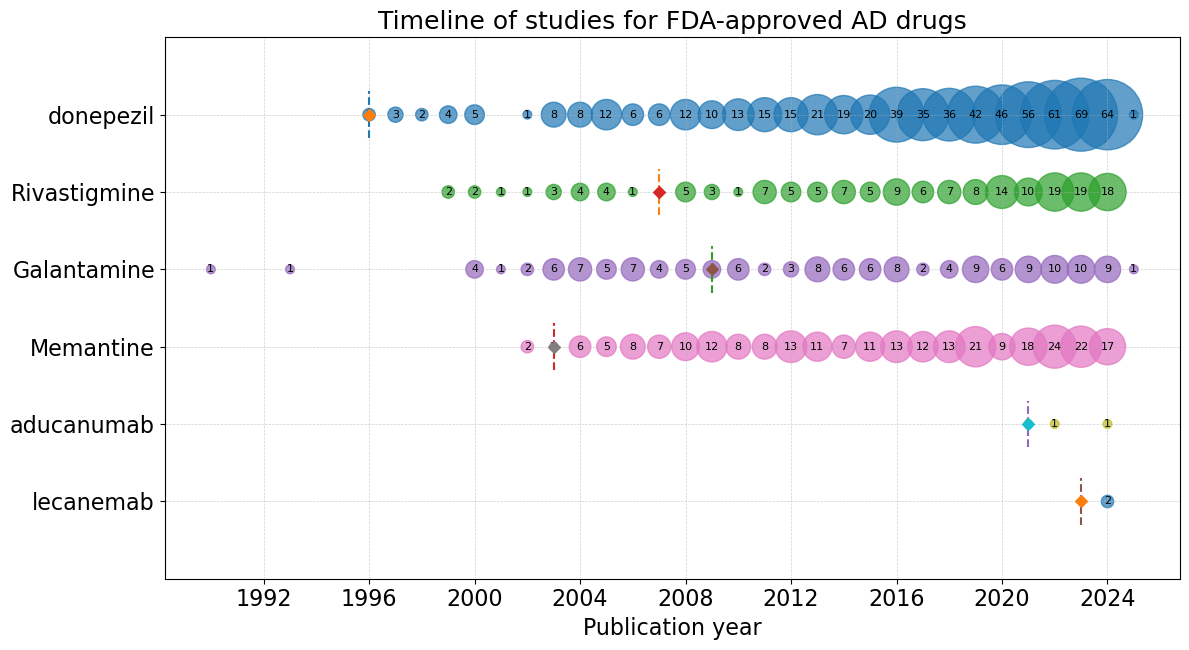

In [427]:
plot_drug_approval_timeline(
    drug_years=drug_years,
    approved_df=approved_df,
    fuzzy_filter=fuzzy_filter,
    title="Timeline of studies for FDA-approved AD drugs",
    output_file="viz/ad_approved_timeline.png"
  
)

In [ ]:
plot_drug_approval_timeline(
    drug_years=drug_years,
    approved_df=approved_df,
    fuzzy_filter=fuzzy_filter,
    title="Timeline of studies for FDA-approved MS drugs",
    output_file="viz/ms_approved_timeline.png",
    drugs_custom_order=[
        'Natalizumab', 'Fingolimod', 'Fumarate, Dimethyl', 'teriflunomide',
        'riTUXimab', 'siponimod', 'Cladribine', 'Monomethyl fumarate',
        'Alemtuzumab', 'ozanimod', 'peginterferon beta-1a', 'ponesimod',
        'ocrelizumab', 'ofatumumab'
    ]
)


In [924]:
# Define the fuzzy filter function
def fuzzy_filter(df, target, threshold=0.9):
    """
    Returns rows where the 'drug' column has a similarity ratio >= threshold with the target string.
    """
    def similarity(a, b):
        return SequenceMatcher(None, a, b).ratio()
    
    mask = df['drug'].apply(lambda x: similarity(x, target) >= threshold)
    return df[mask]

# Build summary using fuzzy matching
summary = []
for drug, appr_year in drug_years.items():
    if appr_year is None:
        continue
    df_sub = fuzzy_filter(approved_df, drug, threshold=0.9)
    total = df_sub['PMID'].nunique()
    before = df_sub[df_sub['year'] <= appr_year]['PMID'].nunique()
    after = df_sub[df_sub['year'] > appr_year]['PMID'].nunique()
    summary.append({
        'drug': drug,
        'approval_year': appr_year,
        'total_unique_pmids': total,
        'before_unique': before,
        'after_unique': after
    })
summary_df = pd.DataFrame(summary)

In [926]:
df_sub = fuzzy_filter(approved_df, "ocrelizumab", threshold=0.90)
df_sub = df_sub.drop_duplicates(subset="PMID")
df_sub

,PMID,unique_conditions_linkbert_predictions_x,unique_interventions_linkbert_predictions_x,year,journal_name,publication_type,title,Unnamed: 0,unique_conditions_linkbert_predictions_y,unique_interventions_linkbert_predictions_y,...,animal_sex,animal_species,animal_age,rigor_blinding,rigor_randomization,rigor_welfare,animal_strain,animal_number,animal_strain_norm,matched_approved
3969,35967378,multiple sclerosis,[111] in-ofatumumab|in|[111] in-ocrelizumab|oc...,2022.0,Frontiers in immunology,"Journal Article+Research Support, Non-U.S. Gov't",Distribution and efficacy of ofatumumab and oc...,394308,multiple sclerosis,in|anti-cd20 monoclonal antibodies|ocrelizumab...,...,sex-not-reported,mouse,unlabeled,blinding-present,randomization-present,welfare-present,"B6, Fvb, Hucd20, Hucd20 C57Bl/6",unlabeled,"B6, Fvb, Hucd20, Hucd20 C57Bl/6",ocrelizumab
5653,30194232,cns autoimmune disease|multiple sclerosis,anti-cd20|anti-cd20 antibody ocrelizumab,2018.0,Proceedings of the National Academy of Science...,"Journal Article+Research Support, Non-U.S. Gov't",Functional characterization of reappearing B c...,570698,cns autoimmune disease|multiple sclerosis,anti-cd20|anti-cd20 antibody ocrelizumab,...,sex-not-reported,species-other,unlabeled,blinding-not-reported,randomization-not-reported,welfare-present,unlabeled,unlabeled,unlabeled,ocrelizumab
5728,39374887,multiple sclerosis,ocrelizumab|anti-human cd20 monoclonal antibod...,2024.0,Pharmacological research,Journal Article,Profiling the impact of anti-human CD20 monocl...,575369,multiple sclerosis,anti-human cd20 monoclonal antibodies|anti-hcd...,...,sex-not-reported,species-other,unlabeled,blinding-not-reported,randomization-not-reported,welfare-not-reported,unlabeled,unlabeled,unlabeled,ocrelizumab


In [608]:
summary_df

,drug,approval_year,total_unique_pmids,before_unique,after_unique
0,Alemtuzumab,2001,20,0,20
1,Cladribine,2019,20,13,6
2,"Fumarate, Dimethyl",2013,103,6,97
3,Fingolimod,2010,235,17,218
4,Monomethyl fumarate,2020,24,16,8
5,Natalizumab,2004,66,1,65
6,ocrelizumab,2017,9,4,5
7,ofatumumab,2009,4,0,4
8,ozanimod,2020,9,2,7
9,peginterferon beta-1a,2014,1,1,0


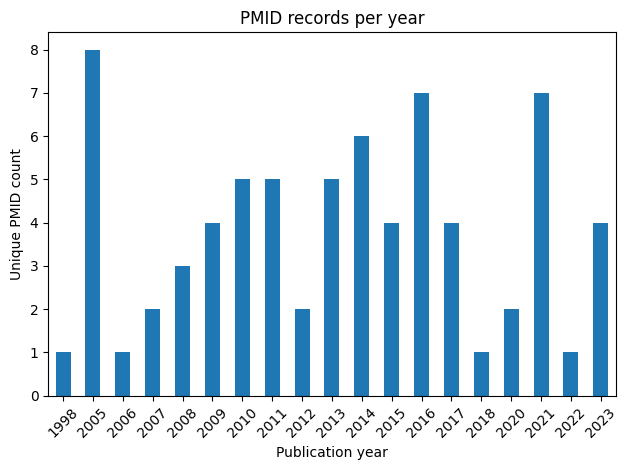

In [213]:
plot_pmid_counts_over_year(fuzzy_filter(approved_df, "Natalizumab", threshold=0.7), 'PMID', 'year')